Author: Krish

In [2]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from datetime import date

In [12]:
data_path = "C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Spring 2025\\STAT390\\LegalAid\\Data\\CAR_-_EP_Flow_Activity_Queue__Agent_Names\\"
adhoc_data_path = 'C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Fall 2025\\LegalAid\\Adhoc\\Adhoc datasets\\'

In [13]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [14]:
i=0
for f in files:
    i = i + 1
    if i == 54:
        break
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [15]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour
df_main.sort_values(by = ['Contact Session ID', 'Activity Start Timestamp'], inplace=True)
df_main.reset_index(inplace = True, drop = True)

In [17]:
def custdata(id):
    return df_main.loc[df_main['Contact Session ID'] == id,:]
def act_rows(act):
    return df_main.loc[df_main['Activity Name'] == act,:]
def act_data(act):
    get_act_rows = act_rows(act)
    return df_main.loc[df_main['Contact Session ID'].isin(get_act_rows['Contact Session ID']),:]
def data_rows(act, data):
    return data.loc[data['Activity Name'] == act,:]
def col_data(col, val):
    get_col_rows = df_main.loc[df_main[col] == val,:]
    return df_main.loc[df_main['Contact Session ID'].isin(get_col_rows['Contact Session ID']),:]
def col_rows(col, val):
    return df_main.loc[df_main[col] == val,:]
def calls_for_activity(act_name):
    return df_main.loc[df_main['Activity Name'] == act_name,'Contact Session ID'].nunique()
def tagging(data):     
    ids_already_present = data.loc[data['Contact Session ID'].isin(all_data['Contact Session ID']),'Contact Session ID'].nunique()
    print("IDs already present in the previously tagged data = ", ids_already_present)
    data = data.loc[~data['Contact Session ID'].isin(all_data['Contact Session ID']),:]
    print("IDs added = ", data['Contact Session ID'].nunique())    
    print("% IDs added = ", round(100*data['Contact Session ID'].nunique()/248422),"%")
    print("IDs per weekday = ", round(data['Contact Session ID'].nunique()/370))
    appended_data = pd.concat([all_data, data])
    print("IDs in tagged data = ", appended_data['Contact Session ID'].nunique())
    print("% data tagged = ", round(100*appended_data['Contact Session ID'].nunique()/248422),"%")
    return appended_data

In [18]:
df_main_copy = df_main.copy()
df_main_copy = df_main_copy.loc[~df_main['Activity Name'].isna(),:]

#### Main-menu only

In [19]:
num_EPs = df_main.groupby('Contact Session ID')['EP Name'].nunique()
one_ep_data = df_main.loc[df_main['Contact Session ID'].isin(num_EPs[num_EPs == 1].index),:]
main_menu_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Main Number Telephony EP',:]
main_menu_data = df_main.loc[df_main['Contact Session ID'].isin(main_menu_rows['Contact Session ID']),:]

num_acts = df_main.groupby('Contact Session ID')['Activity Name'].nunique()
no_acts_rem = df_main.loc[(df_main['Contact Session ID'].isin(num_acts[(num_acts == 0)].index)) & \
(df_main['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'),:]
no_acts_rem_data = df_main.loc[df_main['Contact Session ID'].isin(no_acts_rem['Contact Session ID']),:]

main_menu_data = pd.concat([main_menu_data, no_acts_rem_data])
main_menu_data['caller_type'] = 'Main menu only'
print("% data = ", round(100*98352/248422),"%")
print("calls per day = ", round(98352/370))
print("calls per day = ",main_menu_data['Contact Session ID'].nunique())

% data =  40 %
calls per day =  266
calls per day =  98357


## closed hours

In [20]:
closed_hours_data = col_data('EP Name', 'Closed Hours-Holidays Menu Telephony EP')
closed_hours_data['caller_type'] = 'Closed hours callers'
print(closed_hours_data['Contact Session ID'].nunique())

ids1 = set(main_menu_data["Contact Session ID"])
ids2 = set(closed_hours_data["Contact Session ID"])
common_12 = ids1 & ids2
if len(common_12) == 0:
    print("No overlap with the previously tagged data")

all_data = pd.concat([main_menu_data,closed_hours_data])
print("% data = ", round(100*closed_hours_data['Contact Session ID'].nunique()/248422),"%")
print("calls per day = ", round(closed_hours_data['Contact Session ID'].nunique()/370))
all_data['Contact Session ID'].nunique()

21861
No overlap with the previously tagged data
% data =  9 %
calls per day =  59


120218

### Farmworker data
calls already tagged as during closed hours excluded
Removing farmworker data from analysis due to high abandonment rate

In [21]:
farm_data = act_data('FarmworkerMainMenu')
farmworker_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Farmworker Main Number Telephony EP',:]
farmworker_data = df_main.loc[df_main['Contact Session ID'].isin(farmworker_rows['Contact Session ID']),:]
more_farm_data = farmworker_data.loc[~farmworker_data['Contact Session ID'].isin(farm_data['Contact Session ID']),:]
farm_data = pd.concat([farm_data, more_farm_data])
farm_data['caller_type'] = 'Farmworker'
all_data = tagging(farm_data)

IDs already present in the previously tagged data =  90
IDs added =  10310
% IDs added =  4 %
IDs per weekday =  28
IDs in tagged data =  130528
% data tagged =  53 %


### Non-seniors legal menu
Calls that reach LegalMenu2, but never reach SuburbsOrCityMenu

In [22]:
legmen2_data = act_data('LegalMenu1')
leg_senior_data_rows = data_rows('SuburbsOrCityMenu',legmen2_data)
#Non-seniors never reach the suburbs or city menu
leg_non_senior_data = legmen2_data.loc[~legmen2_data['Contact Session ID'].isin(leg_senior_data_rows['Contact Session ID']),:]
leg_non_senior_data['caller_type'] = 'Non-senior legal issue'
all_data = tagging(leg_non_senior_data)

IDs already present in the previously tagged data =  581
IDs added =  79085
% IDs added =  32 %
IDs per weekday =  214
IDs in tagged data =  209613
% data tagged =  84 %


## Seniors
### Suburban seniors
Calls that reach SuburbanSeniorsMenu menu

In [23]:
suburban_seniors_data = act_data('SuburbanSeniorsMenu')
suburban_seniors_data['caller_type'] = 'Suburban senior'
all_data = tagging(suburban_seniors_data)

IDs already present in the previously tagged data =  14
IDs added =  8305
% IDs added =  3 %
IDs per weekday =  22
IDs in tagged data =  217918
% data tagged =  88 %


### City Seniors

In [24]:
city_seniors = act_data('SeniorsADAPTMenu')
city_seniors['caller_type'] = 'Chicago senior'
all_data = tagging(city_seniors)

IDs already present in the previously tagged data =  55
IDs added =  17975
% IDs added =  7 %
IDs per weekday =  49
IDs in tagged data =  235893
% data tagged =  95 %


### Non cook county seniors

In [25]:
noncook_seniors = act_data('SeniorNotCookCoMenu')
noncook_seniors['caller_type'] = 'Non-Cook County Senior'
all_data = tagging(noncook_seniors)

IDs already present in the previously tagged data =  10
IDs added =  1302
% IDs added =  1 %
IDs per weekday =  4
IDs in tagged data =  237195
% data tagged =  95 %



### Unclassified seniors

In [26]:
#unclassified_seniors = act_data('SuburbsOrCityMenu')
#unclassified_seniors['caller_type'] = 'Unclassified seniors'
#all_data = tagging(unclassified_seniors)

All these seniors abandoned call before making a choice

## Intake outdial EP

In [27]:
intake_rows = one_ep_data.loc[one_ep_data['EP Name'] == 'Intake Outdial EP',:]
intake_outdial_data = df_main.loc[df_main['Contact Session ID'].isin(intake_rows['Contact Session ID']),:]
intake_outdial_data['caller_type'] = 'Intake Outdial'
all_data = tagging(intake_outdial_data)

IDs already present in the previously tagged data =  0
IDs added =  9395
% IDs added =  4 %
IDs per weekday =  25
IDs in tagged data =  246590
% data tagged =  99 %


### Rest

In [28]:
rest_data = df_main.loc[~df_main['Contact Session ID'].isin(all_data['Contact Session ID']),:]

In [29]:
rest_data_nomissact = rest_data.loc[~rest_data['Activity Name'].isna(),:]
last_act = rest_data_nomissact.groupby('Contact Session ID').tail(1)[['Contact Session ID', 'Activity Name']]
rest_data_nomissact.groupby('Contact Session ID').tail(1)[['Activity Name']].value_counts()

Activity Name          
SeniorsMenu                1197
SuburbsOrCityMenu           443
SeniorsConfirmationMenu     211
MainMenu                      1
Name: count, dtype: int64

All these calls are abandoned before information about the caller was obtained

In [30]:
rest_data['caller_type'] = 'unclassified (with access to legal issues menu)'
all_data = tagging(rest_data)

IDs already present in the previously tagged data =  0
IDs added =  1852
% IDs added =  1 %
IDs per weekday =  5
IDs in tagged data =  248442
% data tagged =  100 %


### caller type summary

In [31]:
call_type = pd.DataFrame({'calls':all_data.groupby('caller_type')['Contact Session ID'].nunique().sort_values(ascending = False)})
call_type['percent_calls'] = round(100*call_type['calls'] / 248442)
call_type['calls_per_weekday'] = round(call_type['calls'] / 370)
call_type

,calls,percent_calls,calls_per_weekday
caller_type,,,
Main menu only,98357,40.0,266.0
Non-senior legal issue,79085,32.0,214.0
Closed hours callers,21861,9.0,59.0
Chicago senior,17975,7.0,49.0
Farmworker,10310,4.0,28.0
Intake Outdial,9395,4.0,25.0
Suburban senior,8305,3.0,22.0
unclassified (with access to legal issues menu),1852,1.0,5.0
Non-Cook County Senior,1302,1.0,4.0


In [32]:
all_data['Overall_tag'] = "Legal issue"
all_data.loc[all_data['caller_type'].isin(['Farmworker','Intake Outdial','Closed hours callers']),'Overall_tag'] = 'Other'
all_data.loc[all_data['caller_type'] == 'Main menu only','Overall_tag'] = 'Main menu'
call_type = pd.DataFrame({'calls':all_data.groupby('Overall_tag')['Contact Session ID'].nunique().sort_values(ascending = False)})
call_type['percent_calls'] = round(100*call_type['calls'] / 248442)
call_type['calls_per_weekday'] = round(call_type['calls'] / 370)
call_type

,calls,percent_calls,calls_per_weekday
Overall_tag,,,
Legal issue,108519,44.0,293.0
Main menu,98357,40.0,266.0
Other,41566,17.0,112.0


KeyError: 'outcome_type'

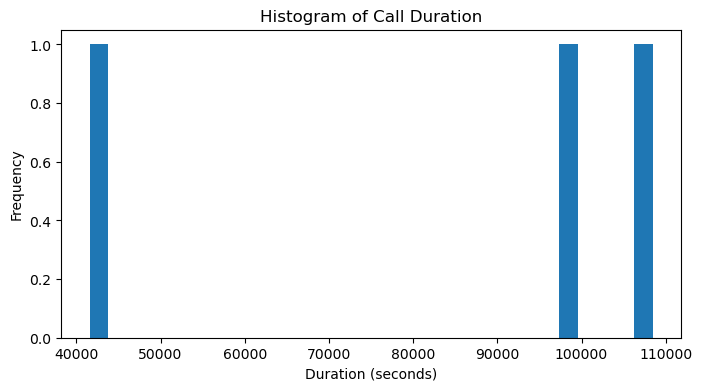

In [22]:
#import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(call_type["calls"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.title("Histogram of Call Duration")
plt.show()




In [35]:
last_act = all_data.loc[~all_data['Activity Name'].isna(),:].groupby('Contact Session ID').tail(1)
no_act_csid = all_data.loc[~all_data['Contact Session ID'].isin(last_act['Contact Session ID']),:]
no_act_csid_last_row = no_act_csid.groupby('Contact Session ID').tail(1)
no_act_csid_last_row['Activity Name'] = 'No activity'

last_act = pd.concat([last_act, no_act_csid_last_row])

last_act.loc[last_act['Activity Name'] == 'OtherLegalMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'OtherLegalMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'OtherLegalMenu', 'outcome_source'] ='OtherLegalMenu'
olm_in_other = df_main.loc[df_main['Activity Name'].isin(['OtherLegalPersonalInjuryMenu','OtherLegalCriminalCaseMenu','OtherLegalOtherMenu']),:]
last_act.loc[(last_act['Activity Name'] == 'OtherLegalMenu') & (last_act['Contact Session ID'].isin(olm_in_other['Contact Session ID'])), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'OtherLegalMenu') & (last_act['Contact Session ID'].isin(olm_in_other['Contact Session ID'])), 'outcome_type'] = 'LAC does not serve'
last_act.loc[(last_act['Activity Name'] == 'OtherLegalMenu') & (last_act['Contact Session ID'].isin(olm_in_other['Contact Session ID'])), 'outcome_source'] = 'OtherLegalMenu'

last_act.loc[last_act['Activity Name'] == 'ClosedQueueMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ClosedQueueMenu', 'outcome_type'] ='Closed queue'
last_act.loc[last_act['Activity Name'] == 'ClosedQueueMenu', 'outcome_source'] ='ClosedQueueMenu'
last_act.loc[last_act['Activity Name'] == 'StaffDirectoryEnglishTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'StaffDirectoryEnglishTransfer', 'outcome_type'] ='Staff directory'
last_act.loc[last_act['Activity Name'] == 'StaffDirectoryEnglishTransfer', 'outcome_source'] ='StaffDirectoryEnglishTransfer'
last_act.loc[last_act['Activity Name'] == 'LanguageSelectionMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'LanguageSelectionMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'LanguageSelectionMenu', 'outcome_source'] ='LanguageSelectionMenu'

last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome'] = 'Negative'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_type'] ='Closed queue'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_source'] ='ClinicVoicemailTransfer (Closed Queue EP)'

last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_type'] ='Closed hours'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_source'] ='ClinicVoicemailTransfer (Closed hours EP)'

last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['outcome'].isna()), 'outcome'] = 'Positive'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['outcome_type'].isna()), 'outcome_type'] ='Clinic voicemail'
last_act.loc[(last_act['Activity Name'] == 'ClinicVoicemailTransfer') & (last_act['outcome_source'].isna()), 'outcome_source'] ='ClinicVoicemailTransfer'

last_act.loc[last_act['Activity Name'] == 'MainMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'MainMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'MainMenu', 'outcome_source'] ='MainMenu'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome'] = 'Negative'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_type'] ='Closed queue'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Queue Menu Telephony EP'), 'outcome_source'] ='DisconnectContact1 (Closed Queue EP)'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_type'] ='Closed hours'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Closed Hours-Holidays Menu Telephony EP'), 'outcome_source'] ='DisconnectContact1 (Closed hours EP)'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'), 'outcome'] = 'Neutral'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'), 'outcome_type'] ='LAC does not serve'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP'), 'outcome_source'] ='DisconnectContact1 (Pre-legal Seniors EP)'

last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Courtesy Callback Telephony EP'), 'outcome'] = 'Negative'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Courtesy Callback Telephony EP'), 'outcome_type'] ='Failed courtsey callback'
last_act.loc[(last_act['Activity Name'] == 'DisconnectContact1') & (last_act['EP Name'] == 'Courtesy Callback Telephony EP'), 'outcome_source'] ='DisconnectContact1 (callback EP)'

last_act.loc[last_act['Activity Name'] == 'LegalMenu2', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'LegalMenu2', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'LegalMenu2', 'outcome_source'] ='LegalMenu2'
last_act.loc[last_act['Activity Name'] == 'FarmworkerMainMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'FarmworkerMainMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'FarmworkerMainMenu', 'outcome_source'] ='FarmworkerMainMenu'
last_act.loc[last_act['Activity Name'] == 'SetCallerID', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'SetCallerID', 'outcome_type'] ='Connected to agent'
last_act.loc[last_act['Activity Name'] == 'SetCallerID', 'outcome_source'] ='SetCallerID'
last_act.loc[last_act['Activity Name'] == 'LegalServerScreenPop', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'LegalServerScreenPop', 'outcome_type'] ='Connected to agent'
last_act.loc[last_act['Activity Name'] == 'LegalServerScreenPop', 'outcome_source'] ='LegalServerScreenPop'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer1', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer1', 'outcome_type'] ='No language selected (FD1)'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer1', 'outcome_source'] ='FrontDeskTransfer1'
last_act.loc[last_act['Activity Name'] == 'ClosedMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ClosedMenu', 'outcome_type'] ='Closed hours'
last_act.loc[last_act['Activity Name'] == 'ClosedMenu', 'outcome_source'] ='ClosedMenu'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer2', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer2', 'outcome_type'] ='Appt / feedback'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer2', 'outcome_source'] ='FrontDeskTransfer2'

last_act.loc[last_act['Activity Name'] == 'StaffDirectorySpanishTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'StaffDirectorySpanishTransfer', 'outcome_type'] ='Staff directory'
last_act.loc[last_act['Activity Name'] == 'StaffDirectorySpanishTransfer', 'outcome_source'] ='StaffDirectorySpanishTransfer'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer', 'outcome_type'] ='Interpreter needed (FD, Legal menu)'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer', 'outcome_source'] ='FrontDeskTransfer'
last_act.loc[last_act['Activity Name'] == 'TenantMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'TenantMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'TenantMenu', 'outcome_source'] ='TenantMenu'
last_act.loc[last_act['Activity Name'] == 'CriminalRecordsVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'CriminalRecordsVoicemailTransfer', 'outcome_type'] ='Criminal Voicemail'
last_act.loc[last_act['Activity Name'] == 'CriminalRecordsVoicemailTransfer', 'outcome_source'] ='CriminalRecordsVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'OtherLegalOtherMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'OtherLegalOtherMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'OtherLegalOtherMenu', 'outcome_source'] ='OtherLegalOtherMenu'
last_act.loc[last_act['Activity Name'] == 'DivorceOrParentingMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'DivorceOrParentingMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'DivorceOrParentingMenu', 'outcome_source'] ='DivorceOrParentingMenu'
last_act.loc[last_act['Activity Name'] == 'QueueMenu1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'QueueMenu1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'QueueMenu1', 'outcome_source'] ='QueueMenu1'
last_act.loc[last_act['Activity Name'] == 'LegalMenu1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'LegalMenu1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'LegalMenu1', 'outcome_source'] ='LegalMenu1'
last_act.loc[last_act['Activity Name'] == 'SeniorsMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SeniorsMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SeniorsMenu', 'outcome_source'] ='SeniorsMenu'
last_act.loc[last_act['Activity Name'] == 'TenantDeterrenceMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'TenantDeterrenceMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'TenantDeterrenceMenu', 'outcome_source'] ='TenantDeterrenceMenu'
last_act.loc[last_act['Activity Name'] == 'HousingMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'HousingMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'HousingMenu', 'outcome_source'] ='HousingMenu'
last_act.loc[last_act['Activity Name'] == 'HIVVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'HIVVoicemailTransfer', 'outcome_type'] ='HIV Voicemail'
last_act.loc[last_act['Activity Name'] == 'HIVVoicemailTransfer', 'outcome_source'] ='HIVVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'PlayMOH300s', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PlayMOH300s', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'PlayMOH300s', 'outcome_source'] ='PlayMOH300s'
last_act.loc[last_act['Activity Name'] == 'HIVMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'HIVMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'HIVMenu', 'outcome_source'] ='HIVMenu'
last_act.loc[last_act['Activity Name'] == 'ScreenPopProcessComplete', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'ScreenPopProcessComplete', 'outcome_type'] ='Connected to agent'
last_act.loc[last_act['Activity Name'] == 'ScreenPopProcessComplete', 'outcome_source'] ='ScreenPopProcessComplete'
last_act.loc[last_act['Activity Name'] == 'AddressFaxHoursMenu', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'AddressFaxHoursMenu', 'outcome_type'] ='Address Voicemail'
last_act.loc[last_act['Activity Name'] == 'AddressFaxHoursMenu', 'outcome_source'] ='AddressFaxHoursMenu'
last_act.loc[last_act['Activity Name'] == 'PreTenantMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'PreTenantMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'PreTenantMenu', 'outcome_source'] ='PreTenantMenu'
last_act.loc[last_act['Activity Name'] == 'FamilyMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'FamilyMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'FamilyMenu', 'outcome_source'] ='FamilyMenu'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer3', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer3', 'outcome_type'] ='No selection on Main menu (FD3)'
last_act.loc[last_act['Activity Name'] == 'FrontDeskTransfer3', 'outcome_source'] ='FrontDeskTransfer3'
last_act.loc[last_act['Activity Name'] == 'ChildSupportMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ChildSupportMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'ChildSupportMenu', 'outcome_source'] ='ChildSupportMenu'
last_act.loc[last_act['Activity Name'] == 'ImmigrationMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ImmigrationMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'ImmigrationMenu', 'outcome_source'] ='ImmigrationMenu'
last_act.loc[last_act['Activity Name'] == 'SeniorsADAPTMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SeniorsADAPTMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SeniorsADAPTMenu', 'outcome_source'] ='SeniorsADAPTMenu'
last_act.loc[last_act['Activity Name'] == 'OtherLegalPersonalInjuryMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'OtherLegalPersonalInjuryMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'OtherLegalPersonalInjuryMenu', 'outcome_source'] ='OtherLegalPersonalInjuryMenu'
last_act.loc[last_act['Activity Name'] == 'OtherLegalCriminalCaseMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'OtherLegalCriminalCaseMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'OtherLegalCriminalCaseMenu', 'outcome_source'] ='OtherLegalCriminalCaseMenu'
last_act.loc[last_act['Activity Name'] == 'SuburbsOrCityMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SuburbsOrCityMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SuburbsOrCityMenu', 'outcome_source'] ='SuburbsOrCityMenu'
last_act.loc[last_act['Activity Name'] == 'SuburbanSeniorsMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SuburbanSeniorsMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SuburbanSeniorsMenu', 'outcome_source'] ='SuburbanSeniorsMenu'
last_act.loc[last_act['Activity Name'] == 'TransferToSafeHaven', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'TransferToSafeHaven', 'outcome_type'] ='Chatbot experiment (Family menu)'
last_act.loc[last_act['Activity Name'] == 'TransferToSafeHaven', 'outcome_source'] ='TransferToSafeHaven'
last_act.loc[last_act['Activity Name'] == 'SimpleDivorceMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'SimpleDivorceMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'SimpleDivorceMenu', 'outcome_source'] ='SimpleDivorceMenu'
last_act.loc[last_act['Activity Name'] == 'BenefitsMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'BenefitsMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'BenefitsMenu', 'outcome_source'] ='BenefitsMenu'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_1', 'outcome_source'] ='SubSeniorPreQueueMessage1_1'
last_act.loc[last_act['Activity Name'] == 'ThankYouGoodbye', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ThankYouGoodbye', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'ThankYouGoodbye', 'outcome_source'] ='ThankYouGoodbye'
last_act.loc[last_act['Activity Name'] == 'IntakePreQueueMessage1', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'IntakePreQueueMessage1', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'IntakePreQueueMessage1', 'outcome_source'] ='IntakePreQueueMessage1'
last_act.loc[last_act['Activity Name'] == 'SeniorsConfirmationMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SeniorsConfirmationMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SeniorsConfirmationMenu', 'outcome_source'] ='SeniorsConfirmationMenu'
last_act.loc[last_act['Activity Name'] == 'VeteransBenefitsVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'VeteransBenefitsVoicemailTransfer', 'outcome_type'] ='Veterans Voicemail'
last_act.loc[last_act['Activity Name'] == 'VeteransBenefitsVoicemailTransfer', 'outcome_source'] ='VeteransBenefitsVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'EmploymentMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'EmploymentMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'EmploymentMenu', 'outcome_source'] ='EmploymentMenu'
last_act.loc[last_act['Activity Name'] == 'No activity', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'No activity', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'No activity', 'outcome_source'] ='No activity'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact2', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact2', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact2', 'outcome_source'] ='DisconnectContact2'
last_act.loc[last_act['Activity Name'] == 'TraffickingVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'TraffickingVoicemailTransfer', 'outcome_type'] ='Trafficking Voicemail'
last_act.loc[last_act['Activity Name'] == 'TraffickingVoicemailTransfer', 'outcome_source'] ='TraffickingVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'AppointmentMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'AppointmentMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'AppointmentMenu', 'outcome_source'] ='AppointmentMenu'
last_act.loc[last_act['Activity Name'] == 'SeniorNotCookCoMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'SeniorNotCookCoMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'SeniorNotCookCoMenu', 'outcome_source'] ='SeniorNotCookCoMenu'
last_act.loc[last_act['Activity Name'] == 'ImmigrationOtherMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'ImmigrationOtherMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'ImmigrationOtherMenu', 'outcome_source'] ='ImmigrationOtherMenu'
last_act.loc[last_act['Activity Name'] == 'HolidayPrompt', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'HolidayPrompt', 'outcome_type'] ='Closed hours'
last_act.loc[last_act['Activity Name'] == 'HolidayPrompt', 'outcome_source'] ='HolidayPrompt'
last_act.loc[last_act['Activity Name'] == 'DisconnectCallbackContact', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'DisconnectCallbackContact', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'DisconnectCallbackContact', 'outcome_source'] ='DisconnectCallbackContact'
last_act.loc[last_act['Activity Name'] == 'MigrantVoicemailTransfer', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'MigrantVoicemailTransfer', 'outcome_type'] ='Farmworker Voicemail'
last_act.loc[last_act['Activity Name'] == 'MigrantVoicemailTransfer', 'outcome_source'] ='MigrantVoicemailTransfer'
last_act.loc[last_act['Activity Name'] == 'ComplimentOrComplaintMenu', 'outcome'] = 'Positive'
last_act.loc[last_act['Activity Name'] == 'ComplimentOrComplaintMenu', 'outcome_type'] ='Feedback'
last_act.loc[last_act['Activity Name'] == 'ComplimentOrComplaintMenu', 'outcome_source'] ='ComplimentOrComplaintMenu'
last_act.loc[last_act['Activity Name'] == 'PreQueueMessage2', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PreQueueMessage2', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'PreQueueMessage2', 'outcome_source'] ='PreQueueMessage2'
last_act.loc[last_act['Activity Name'] == 'HelpWithLegalorOtherReasonMenu', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'HelpWithLegalorOtherReasonMenu', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'HelpWithLegalorOtherReasonMenu', 'outcome_source'] ='HelpWithLegalorOtherReasonMenu'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact', 'outcome_type'] ='Outbound call failed'
last_act.loc[last_act['Activity Name'] == 'DisconnectContact', 'outcome_source'] ='DisconnectContact'
last_act.loc[last_act['Activity Name'] == 'WorkersCompMenu', 'outcome'] = 'Neutral'
last_act.loc[last_act['Activity Name'] == 'WorkersCompMenu', 'outcome_type'] ='LAC does not serve'
last_act.loc[last_act['Activity Name'] == 'WorkersCompMenu', 'outcome_source'] ='WorkersCompMenu'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantAgents', 'outcome_source'] ='GetLoggedInSubSeniorTenantAgents'
last_act.loc[last_act['Activity Name'] == 'ReadANI', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ReadANI', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'ReadANI', 'outcome_source'] ='ReadANI'
last_act.loc[last_act['Activity Name'] == 'PlayErrorMessage', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PlayErrorMessage', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'PlayErrorMessage', 'outcome_source'] ='PlayErrorMessage'
last_act.loc[last_act['Activity Name'] == 'CallbackRetry', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'CallbackRetry', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'CallbackRetry', 'outcome_source'] ='CallbackRetry'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherAgents', 'outcome_source'] ='GetLoggedInSubSeniorOtherAgents'
last_act.loc[last_act['Activity Name'] == 'CollectCallbackNumber', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'CollectCallbackNumber', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'CollectCallbackNumber', 'outcome_source'] ='CollectCallbackNumber'
last_act.loc[last_act['Activity Name'] == 'ConfirmCallbackNumber', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ConfirmCallbackNumber', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'ConfirmCallbackNumber', 'outcome_source'] ='ConfirmCallbackNumber'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_2', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_2', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorPreQueueMessage1_2', 'outcome_source'] ='SubSeniorPreQueueMessage1_2'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherSPAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherSPAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorOtherSPAgents', 'outcome_source'] ='GetLoggedInSubSeniorOtherSPAgents'
last_act.loc[last_act['Activity Name'] == 'SubSeniorOtherQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorOtherQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorOtherQueue', 'outcome_source'] ='SubSeniorOtherQueue'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInConsumerAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInConsumerAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInConsumerAgents', 'outcome_source'] ='GetLoggedInConsumerAgents'
last_act.loc[last_act['Activity Name'] == 'ImmigrationSPQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'ImmigrationSPQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'ImmigrationSPQueue', 'outcome_source'] ='ImmigrationSPQueue'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInOtherSubSeniorsAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInOtherSubSeniorsAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInOtherSubSeniorsAgents', 'outcome_source'] ='GetLoggedInOtherSubSeniorsAgents'
last_act.loc[last_act['Activity Name'] == 'SubSeniorTenantQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorTenantQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorTenantQueue', 'outcome_source'] ='SubSeniorTenantQueue'
last_act.loc[last_act['Activity Name'] == 'EducationSPQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'EducationSPQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'EducationSPQueue', 'outcome_source'] ='EducationSPQueue'
last_act.loc[last_act['Activity Name'] == 'PlayCCBConfirmation', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'PlayCCBConfirmation', 'outcome_type'] ='Failed courtsey callback'
last_act.loc[last_act['Activity Name'] == 'PlayCCBConfirmation', 'outcome_source'] ='PlayCCBConfirmation'
last_act.loc[last_act['Activity Name'] == 'SubSeniorHomeownerQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorHomeownerQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorHomeownerQueue', 'outcome_source'] ='SubSeniorHomeownerQueue'
last_act.loc[last_act['Activity Name'] == 'SubSeniorConsumerQueue', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'SubSeniorConsumerQueue', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'SubSeniorConsumerQueue', 'outcome_source'] ='SubSeniorConsumerQueue'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantSPAgents', 'outcome'] = 'Negative'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantSPAgents', 'outcome_type'] ='Abandoned'
last_act.loc[last_act['Activity Name'] == 'GetLoggedInSubSeniorTenantSPAgents', 'outcome_source'] ='GetLoggedInSubSeniorTenantSPAgents'


In [41]:
last_act['EP Name'].value_counts()

EP Name
Main Number Telephony EP                    98670
Closed Queue Menu Telephony EP              49933
Closed Hours-Holidays Menu Telephony EP     21726
Legal Menu Telephony EP                     18066
Other Legal Menu Telephony EP               12237
Farmworker Main Number Telephony EP          9864
Intake Outdial EP                            9395
Courtesy Callback Telephony EP               9077
Legal Housing Menu Telephony EP              5391
Pre-Legal Menu Seniors Menu Telephony EP     3908
Legal Family Menu Telephony EP               3737
All LAC Queues Telephony EP                  3351
Legal HIV Menu Telephony EP                  1607
Legal Immigration Menu Telephony EP           782
Legal Benefits Menu Telephony EP              483
Legal Employment Menu Telephony EP            214
Name: count, dtype: int64

In [46]:
last_act.loc[last_act['EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP','outcome_type'].value_counts()

outcome_type
Abandoned             2814
LAC does not serve    1094
Name: count, dtype: int64

In [51]:
non_missing_EP = all_data.loc[~all_data['EP Name'].isna(),:]

In [53]:
all_data.shape

(3328626, 11)

In [52]:
non_missing_EP.shape

(2537218, 11)

In [66]:
df = all_data.copy()

In [67]:
special_eps = [
    "Closed Queue Menu Telephony EP",
    "Courtesy Callback Telephony EP",
    "All LAC Queues Telephony EP"
]

def get_final_ep(group):
    # Drop missing EP names
    ep = group["EP Name"].dropna()
    if ep.empty:
        return np.nan
    
    # Walk upward from the bottom
    for ep_name in reversed(ep.tolist()):
        if ep_name not in special_eps:
            return ep_name
    
    # If EVERYTHING is a special EP → return the last EP anyway
    return ep.iloc[-1]

# Apply per Contact Session ID
final_ep_per_session = (
    df.groupby("Contact Session ID", as_index=False)
      .apply(lambda g: pd.Series({"Final EP Name": get_final_ep(g)}))
)

# Optional: merge back to original df
df = df.merge(final_ep_per_session, on="Contact Session ID", how="left")

In [68]:
df['Final EP Name'].value_counts()

Final EP Name
Main Number Telephony EP                    868283
Legal Family Menu Telephony EP              473166
Legal Menu Telephony EP                     442262
Legal Housing Menu Telephony EP             364271
Pre-Legal Menu Seniors Menu Telephony EP    266564
Other Legal Menu Telephony EP               216293
Closed Hours-Holidays Menu Telephony EP     200321
Legal Benefits Menu Telephony EP            154777
Legal Employment Menu Telephony EP           95197
Intake Outdial EP                            90590
Legal Immigration Menu Telephony EP          68330
Farmworker Main Number Telephony EP          60721
Legal HIV Menu Telephony EP                  27851
Name: count, dtype: int64

In [70]:
final_ep_per_session['Final EP Name'].value_counts()

Final EP Name
Main Number Telephony EP                    98535
Legal Menu Telephony EP                     27533
Legal Family Menu Telephony EP              22743
Closed Hours-Holidays Menu Telephony EP     21861
Legal Housing Menu Telephony EP             16485
Pre-Legal Menu Seniors Menu Telephony EP    12938
Other Legal Menu Telephony EP               12204
Farmworker Main Number Telephony EP          9864
Intake Outdial EP                            9395
Legal Benefits Menu Telephony EP             7205
Legal Employment Menu Telephony EP           4562
Legal Immigration Menu Telephony EP          3514
Legal HIV Menu Telephony EP                  1603
Name: count, dtype: int64

In [90]:
tagged_data['caller_type'].value_counts().sum()

248442

In [91]:
last_act['outcome_type'].value_counts()

outcome_type
Abandoned                              76739
Closed queue                           49933
Staff directory                        31994
Connected to agent                     18991
Closed hours                           18573
Clinic voicemail                       16498
LAC does not serve                     13046
No language selected (FD1)              7890
Appt / feedback                         6895
Interpreter needed (FD, Legal menu)     2545
Criminal Voicemail                      2267
HIV Voicemail                            836
Address Voicemail                        672
No selection on Main menu (FD3)          541
Chatbot experiment (Family menu)         412
Veterans Voicemail                       185
Trafficking Voicemail                    139
Failed courtsey callback                 129
Farmworker Voicemail                      67
Feedback                                  58
Outbound call failed                      32
Name: count, dtype: int64

In [113]:
last_act['caller_type'].value_counts()

caller_type
Main menu only                                     98357
Non-senior legal issue                             79085
Closed hours callers                               21861
Chicago senior                                     17975
Farmworker                                         10310
Intake Outdial                                      9395
Suburban senior                                     8305
unclassified (with access to legal issues menu)     1852
Non-Cook County Senior                              1302
Name: count, dtype: int64

In [114]:
non_seniors = last_act.loc[last_act['caller_type'] == 'Non-senior legal issue',:]

In [117]:
non_seniors_queue = non_seniors.loc[non_seniors['Activity Name'].isin(['ClosedQueueMenu','LegalServerScreenPop',
            'QueueMenu1','ScreenPopProcessComplete','PlayMOH300s','IntakePreQueueMessage1','DisconnectCallbackContact',
                                                                      'PreQueueMessage2','CallbackRetry','ConfirmCallbackNumber',
                                                                      'CollectCallbackNumber','EducationSPQueue',
                                                                      'PlayCCBConfirmation','ImmigrationSPQueue']),:]

In [118]:
non_seniors_queue.shape

(37464, 14)

In [116]:
non_seniors['Activity Name'].value_counts()

Activity Name
ClosedQueueMenu                      31755
LegalMenu2                            9980
ClinicVoicemailTransfer               7224
OtherLegalMenu                        5449
LegalServerScreenPop                  4539
FrontDeskTransfer                     2273
CriminalRecordsVoicemailTransfer      2001
TenantMenu                            1996
OtherLegalOtherMenu                   1624
DisconnectContact1                    1498
DivorceOrParentingMenu                1348
LegalMenu1                            1087
TenantDeterrenceMenu                   755
HousingMenu                            706
HIVVoicemailTransfer                   704
HIVMenu                                690
ChildSupportMenu                       517
FamilyMenu                             493
ImmigrationMenu                        465
OtherLegalCriminalCaseMenu             415
PreTenantMenu                          415
QueueMenu1                             410
OtherLegalPersonalInjuryMenu           3

In [99]:
seniors_custs = all_data.loc[all_data['Activity Name'].isin(['SuburbanSeniorsMenu','SeniorsADAPTMenu']),:]

In [100]:
seniors_custs['Contact Session ID'].nunique()

26347

In [101]:
tags = tagged_data.loc[tagged_data['Contact Session ID'].isin(seniors_custs['Contact Session ID']),:]

In [103]:
tags['Contact Session ID'].nunique()

26347

In [105]:
abandoned = tags.loc[tags['outcome_type'] == 'Abandoned',:]

In [106]:
abandoned.shape

(5745, 16)

In [107]:
5745/26347

0.21805139105021445

In [109]:
abandoned['Activity Name'].value_counts()

Activity Name
LegalMenu2                            1891
QueueMenu1                             874
PlayMOH300s                            541
SeniorsADAPTMenu                       502
SuburbanSeniorsMenu                    442
TenantMenu                             385
SubSeniorPreQueueMessage1_1            278
LegalMenu1                             173
HousingMenu                            129
DivorceOrParentingMenu                 106
HIVMenu                                 75
OtherLegalMenu                          69
ImmigrationMenu                         47
FamilyMenu                              45
BenefitsMenu                            43
IntakePreQueueMessage1                  31
PreQueueMessage2                        28
GetLoggedInSubSeniorTenantAgents        27
EmploymentMenu                          21
MainMenu                                14
GetLoggedInSubSeniorOtherAgents          8
SubSeniorPreQueueMessage1_2              4
SubSeniorOtherQueue                     

In [110]:
filter_aba = abandoned.loc[~abandoned['Activity Name'].isin(['QueueMenu1','PlayMOH300s','SubSeniorPreQueueMessage1_1',
                                                           'IntakePreQueueMessage1','PreQueueMessage2',
                                                           'GetLoggedInSubSeniorTenantAgent','SubSeniorPreQueueMessage1_2',
                                                           'SubSeniorOtherQueue','GetLoggedInSubSeniorOtherSPAgents','CollectCallbackNumber',
                                                           'SubSeniorConsumerQueue','SubSeniorTenantQueue',
                                                           'GetLoggedInOtherSubSeniorsAgents','GetLoggedInSubSeniorTenantSPAgents',
                                                           'SubSeniorHomeownerQueue','GetLoggedInConsumerAgents']),:]

In [111]:
filter_aba.shape

(3977, 16)

In [ ]:
1891

In [112]:
filter_aba['Contact Session ID'].nunique()

3977

In [96]:
tagged_data.loc[tagged_data['Activity Name'].isin([''])

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,outcome,outcome_type,outcome_source,Final EP Name,Clinic_voicemail
0,00002422-f51f-458b-82d6-cfa5a3f36fd9,Main Number Telephony EP,NaN,StaffDirectoryEnglishTransfer,2025-03-13 12:51:41,NaN,NaN,NaN,12,Main menu only,Main menu,Positive,Staff directory,StaffDirectoryEnglishTransfer,Main Number Telephony EP,0
1,00011655-35de-476f-9a8c-dd48ed4d914a,Main Number Telephony EP,NaN,FrontDeskTransfer2,2024-11-06 14:42:14,NaN,NaN,NaN,14,Main menu only,Main menu,Positive,Appt / feedback,FrontDeskTransfer2,Main Number Telephony EP,0
2,000183bb-0f39-4d50-87b9-747243d939bc,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-16 12:13:15,NaN,NaN,NaN,12,Main menu only,Main menu,Negative,Abandoned,LanguageSelectionMenu,Main Number Telephony EP,0
3,00023e47-b722-4e2f-b2e2-855911d085fd,Main Number Telephony EP,NaN,MainMenu,2024-05-29 10:55:39,NaN,NaN,NaN,10,Main menu only,Main menu,Negative,Abandoned,MainMenu,Main Number Telephony EP,0
4,0002606f-910e-43e5-aac5-d93fefc1cead,Main Number Telephony EP,NaN,FrontDeskTransfer1,2025-06-04 10:18:42,NaN,NaN,NaN,10,Main menu only,Main menu,Neutral,No language selected (FD1),FrontDeskTransfer1,Main Number Telephony EP,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248437,03d6ebbc-1aa0-450b-92bb-33e6ec1055d0,Intake Outdial EP,NaN,No activity,2025-04-08 12:40:55,Intake Outdial Queue,NaN,System Error,12,Intake Outdial,Other,Negative,Abandoned,No activity,Intake Outdial EP,0
248438,04d6296e-d77b-4c90-80dd-b194a8e653a7,Intake Outdial EP,NaN,No activity,2024-12-10 15:14:51,Intake Outdial Queue,NaN,NaN,15,Intake Outdial,Other,Negative,Abandoned,No activity,Intake Outdial EP,0
248439,9ea8713f-2699-46c0-8a9f-0db377d6ea7e,Intake Outdial EP,NaN,No activity,2025-07-11 14:47:21,Intake Outdial Queue,NaN,System Error,14,Intake Outdial,Other,Negative,Abandoned,No activity,Intake Outdial EP,0
248440,a75f58a9-aead-44eb-a1bb-b47710921031,Intake Outdial EP,NaN,No activity,2025-07-25 11:13:23,Intake Outdial Queue,NaN,System Error,11,Intake Outdial,Other,Negative,Abandoned,No activity,Intake Outdial EP,0


In [95]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['Clinic_voicemail'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Clinic voicemail','Clinic_voicemail'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('Clinic_voicemail', 'count'),   aba=('Clinic_voicemail', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)

,,tot,aba,ratio
caller_type,Final EP Name,,,
Chicago senior,Other Legal Menu Telephony EP,2912,1004,0.344780
Farmworker,Other Legal Menu Telephony EP,18,4,0.222222
Non-senior legal issue,Main Number Telephony EP,136,21,0.154412
Non-Cook County Senior,Other Legal Menu Telephony EP,99,15,0.151515
Chicago senior,Main Number Telephony EP,47,7,0.148936
Non-senior legal issue,Other Legal Menu Telephony EP,9175,1322,0.144087
Main menu only,Main Number Telephony EP,98352,12922,0.131385
Farmworker,Legal Housing Menu Telephony EP,39,4,0.102564
Chicago senior,Legal Housing Menu Telephony EP,3623,194,0.053547


In [94]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['Connected_to_agent'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Connected to agent','Connected_to_agent'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('Connected_to_agent', 'count'),   aba=('Connected_to_agent', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)

tot  \
caller_type                                     Final EP Name                                     
Intake Outdial                                  Intake Outdial EP                          9395   
Suburban senior                                 Pre-Legal Menu Seniors Menu Telephony EP   8305   
Farmworker                                      Pre-Legal Menu Seniors Menu Telephony EP     26   
Non-Cook County Senior                          Legal Employment Menu Telephony EP           33   
Farmworker                                      Legal Benefits Menu Telephony EP             16   
Non-senior legal issue                          Legal Employment Menu Telephony EP         3997   
Chicago senior                                  Legal Benefits Menu Telephony EP           2045   
                                                Legal Employment Menu Telephony EP          504   
                                                Legal Housing Menu Telephony EP            3623   
Non-senior legal issue                          Legal Benefits Menu Telephony EP           5111   
Non-Cook County Senior                          Legal Family Menu Telephony EP               88   
Chicago senior                                  Legal Family Menu Telephony EP             1721   
                                                Pre-Legal Menu Seniors Menu Telephony EP   2009   
Non-senior legal issue                          Legal Housing Menu Telephony EP           12769   
                                                Legal Family Menu Telephony EP            20762   
Farmworker                                      Legal Immigration Menu Telephony EP          62   
Non-Cook County Senior                          Legal Benefits Menu Telephony EP             33   
Chicago senior                                  Legal Menu Telephony EP                    4736   
Non-senior legal issue                          Legal Immigration Menu Telephony EP        3268   
Farmworker                                      Legal Family Menu Telephony EP              172   
                                                Legal Employment Menu Telephony EP           28   
Non-Cook County Senior                          Legal Menu Telephony EP                     184   
Non-senior legal issue                          Legal Menu Telephony EP                   22469   
Chicago senior                                  Legal Immigration Menu Telephony EP         177   
Non-Cook County Senior                          Legal Housing Menu Telephony EP              54   
Non-senior legal issue                          Legal HIV Menu Telephony EP                1392   
Non-Cook County Senior                          Pre-Legal Menu Seniors Menu Telephony EP    799   
Non-senior legal issue                          Main Number Telephony EP                    136   
                                                Other Legal Menu Telephony EP              9175   
                                                Pre-Legal Menu Seniors Menu Telephony EP      6   
unclassified (with access to legal issues menu) Legal Menu Telephony EP                      64   
Main menu only                                  Pre-Legal Menu Seniors Menu Telephony EP      5   
Non-Cook County Senior                          Other Legal Menu Telephony EP                99   
                                                Legal Immigration Menu Telephony EP           7   
                                                Legal HIV Menu Telephony EP                   5   
Main menu only                                  Main Number Telephony EP                  98352   
Farmworker                                      Other Legal Menu Telephony EP                18   
                                                Legal Menu Telephony EP                      80   
                                                Legal Housing Menu Telephony EP              39   
                                 

In [93]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['Closed_queue'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Closed queue','Closed_queue'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('Closed_queue', 'count'),   aba=('Closed_queue', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)

tot  \
caller_type                                     Final EP Name                                     
Farmworker                                      Legal Family Menu Telephony EP              172   
                                                Legal Employment Menu Telephony EP           28   
Non-Cook County Senior                          Legal Housing Menu Telephony EP              54   
Chicago senior                                  Legal Employment Menu Telephony EP          504   
Non-Cook County Senior                          Legal Employment Menu Telephony EP           33   
Non-senior legal issue                          Legal Employment Menu Telephony EP         3997   
                                                Legal Benefits Menu Telephony EP           5111   
Chicago senior                                  Legal Benefits Menu Telephony EP           2045   
Non-Cook County Senior                          Legal Benefits Menu Telephony EP             33   
Farmworker                                      Legal Benefits Menu Telephony EP             16   
Non-senior legal issue                          Legal Family Menu Telephony EP            20762   
                                                Legal Immigration Menu Telephony EP        3268   
Chicago senior                                  Legal Family Menu Telephony EP             1721   
Non-Cook County Senior                          Legal Family Menu Telephony EP               88   
Chicago senior                                  Pre-Legal Menu Seniors Menu Telephony EP   2009   
                                                Legal Housing Menu Telephony EP            3623   
Farmworker                                      Legal Immigration Menu Telephony EP          62   
Non-senior legal issue                          Legal Housing Menu Telephony EP           12769   
Chicago senior                                  Legal Immigration Menu Telephony EP         177   
Farmworker                                      Legal Housing Menu Telephony EP              39   
Chicago senior                                  Legal Menu Telephony EP                    4736   
Non-Cook County Senior                          Legal Menu Telephony EP                     184   
Suburban senior                                 Pre-Legal Menu Seniors Menu Telephony EP   8305   
Non-Cook County Senior                          Legal Immigration Menu Telephony EP           7   
Non-senior legal issue                          Legal Menu Telephony EP                   22469   
Farmworker                                      Legal Menu Telephony EP                      80   
                                                Pre-Legal Menu Seniors Menu Telephony EP     26   
unclassified (with access to legal issues menu) Legal Menu Telephony EP                      64   
Non-senior legal issue                          Legal HIV Menu Telephony EP                1392   
                                                Main Number Telephony EP                    136   
                                                Other Legal Menu Telephony EP              9175   
                                                Pre-Legal Menu Seniors Menu Telephony EP      6   
Main menu only                                  Pre-Legal Menu Seniors Menu Telephony EP      5   
Non-Cook County Senior                          Pre-Legal Menu Seniors Menu Telephony EP    799   
                                                Other Legal Menu Telephony EP                99   
                                                Legal HIV Menu Telephony EP                   5   
Main menu only                                  Main Number Telephony EP                  98352   
Intake Outdial                                  Intake Outdial EP                          9395   
Farmworker                                      Other Legal Menu Telephony EP                18   
                                 

In [119]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['LAC_no_serve'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'LAC does not serve','LAC_no_serve'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('LAC_no_serve', 'count'),   aba=('LAC_no_serve', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)

tot  \
caller_type                                     Final EP Name                                     
Non-Cook County Senior                          Pre-Legal Menu Seniors Menu Telephony EP    799   
Non-senior legal issue                          Other Legal Menu Telephony EP              9175   
Non-Cook County Senior                          Other Legal Menu Telephony EP                99   
Farmworker                                      Other Legal Menu Telephony EP                18   
Chicago senior                                  Other Legal Menu Telephony EP              2912   
Farmworker                                      Pre-Legal Menu Seniors Menu Telephony EP     26   
                                                Legal Housing Menu Telephony EP              39   
Non-Cook County Senior                          Legal Family Menu Telephony EP               88   
Non-senior legal issue                          Legal Housing Menu Telephony EP           12769   
Chicago senior                                  Legal Immigration Menu Telephony EP         177   
                                                Legal Housing Menu Telephony EP            3623   
Non-Cook County Senior                          Legal Housing Menu Telephony EP              54   
Non-senior legal issue                          Legal Family Menu Telephony EP            20762   
Farmworker                                      Legal Employment Menu Telephony EP           28   
Chicago senior                                  Legal Family Menu Telephony EP             1721   
Suburban senior                                 Pre-Legal Menu Seniors Menu Telephony EP   8305   
Non-senior legal issue                          Legal Immigration Menu Telephony EP        3268   
Farmworker                                      Legal Immigration Menu Telephony EP          62   
Chicago senior                                  Legal Employment Menu Telephony EP          504   
Non-senior legal issue                          Legal Employment Menu Telephony EP         3997   
                                                Legal Menu Telephony EP                   22469   
Chicago senior                                  Legal Menu Telephony EP                    4736   
Non-senior legal issue                          Legal HIV Menu Telephony EP                1392   
Non-Cook County Senior                          Legal Menu Telephony EP                     184   
Non-senior legal issue                          Main Number Telephony EP                    136   
                                                Legal Benefits Menu Telephony EP           5111   
                                                Pre-Legal Menu Seniors Menu Telephony EP      6   
unclassified (with access to legal issues menu) Legal Menu Telephony EP                      64   
Chicago senior                                  Legal Benefits Menu Telephony EP           2045   
Main menu only                                  Pre-Legal Menu Seniors Menu Telephony EP      5   
Non-Cook County Senior                          Legal Immigration Menu Telephony EP           7   
                                                Legal HIV Menu Telephony EP                   5   
                                                Legal Employment Menu Telephony EP           33   
                                                Legal Benefits Menu Telephony EP             33   
Main menu only                                  Main Number Telephony EP                  98352   
Intake Outdial                                  Intake Outdial EP                          9395   
Farmworker                                      Legal Menu Telephony EP                      80   
                                                Legal HIV Menu Telephony EP                   5   
                                                Legal Family Menu Telephony EP              172   
                                 

In [120]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['abandoned'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned','abandoned'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('abandoned', 'count'),   aba=('abandoned', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)

tot  \
caller_type                                     Final EP Name                                     
Main menu only                                  Pre-Legal Menu Seniors Menu Telephony EP      5   
Non-senior legal issue                          Pre-Legal Menu Seniors Menu Telephony EP      6   
unclassified (with access to legal issues menu) Legal Menu Telephony EP                      64   
                                                Pre-Legal Menu Seniors Menu Telephony EP   1788   
Farmworker                                      Farmworker Main Number Telephony EP        9864   
Non-Cook County Senior                          Legal HIV Menu Telephony EP                   5   
Farmworker                                      Legal Menu Telephony EP                      80   
Non-Cook County Senior                          Legal Immigration Menu Telephony EP           7   
Non-senior legal issue                          Legal Menu Telephony EP                   22469   
                                                Legal HIV Menu Telephony EP                1392   
Chicago senior                                  Legal Menu Telephony EP                    4736   
Non-Cook County Senior                          Legal Menu Telephony EP                     184   
Main menu only                                  Main Number Telephony EP                  98352   
Farmworker                                      Legal HIV Menu Telephony EP                   5   
                                                Pre-Legal Menu Seniors Menu Telephony EP     26   
Chicago senior                                  Legal HIV Menu Telephony EP                 201   
Non-senior legal issue                          Main Number Telephony EP                    136   
Chicago senior                                  Main Number Telephony EP                     47   
                                                Legal Immigration Menu Telephony EP         177   
                                                Pre-Legal Menu Seniors Menu Telephony EP   2009   
Farmworker                                      Legal Housing Menu Telephony EP              39   
Suburban senior                                 Pre-Legal Menu Seniors Menu Telephony EP   8305   
Non-senior legal issue                          Legal Housing Menu Telephony EP           12769   
Farmworker                                      Legal Immigration Menu Telephony EP          62   
Non-senior legal issue                          Legal Immigration Menu Telephony EP        3268   
Chicago senior                                  Legal Housing Menu Telephony EP            3623   
Farmworker                                      Legal Benefits Menu Telephony EP             16   
Non-Cook County Senior                          Legal Family Menu Telephony EP               88   
Non-senior legal issue                          Legal Family Menu Telephony EP            20762   
Chicago senior                                  Legal Family Menu Telephony EP             1721   
Non-Cook County Senior                          Legal Housing Menu Telephony EP              54   
Farmworker                                      Legal Employment Menu Telephony EP           28   
Non-senior legal issue                          Legal Benefits Menu Telephony EP           5111   
                                                Legal Employment Menu Telephony EP         3997   
Chicago senior                                  Legal Employment Menu Telephony EP          504   
Farmworker                                      Legal Family Menu Telephony EP              172   
Non-Cook County Senior                          Other Legal Menu Telephony EP                99   
Chicago senior                                  Legal Benefits Menu Telephony EP           2045   
Non-senior legal issue                          Other Legal Menu Telephony EP              9175   
Non-Cook County Senior           

In [133]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['abandoned'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned','abandoned'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('abandoned', 'count'),   aba=('abandoned', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
#summary.sort_values(by = 'ratio', ascending = False)
summary

tot  \
caller_type                                     Final EP Name                                     
Chicago senior                                  Legal Benefits Menu Telephony EP           2045   
                                                Legal Employment Menu Telephony EP          504   
                                                Legal Family Menu Telephony EP             1721   
                                                Legal HIV Menu Telephony EP                 201   
                                                Legal Housing Menu Telephony EP            3623   
                                                Legal Immigration Menu Telephony EP         177   
                                                Legal Menu Telephony EP                    4736   
                                                Main Number Telephony EP                     47   
                                                Other Legal Menu Telephony EP              2912   
                                                Pre-Legal Menu Seniors Menu Telephony EP   2009   
Closed hours callers                            Closed Hours-Holidays Menu Telephony EP   21861   
Farmworker                                      Farmworker Main Number Telephony EP        9864   
                                                Legal Benefits Menu Telephony EP             16   
                                                Legal Employment Menu Telephony EP           28   
                                                Legal Family Menu Telephony EP              172   
                                                Legal HIV Menu Telephony EP                   5   
                                                Legal Housing Menu Telephony EP              39   
                                                Legal Immigration Menu Telephony EP          62   
                                                Legal Menu Telephony EP                      80   
                                                Other Legal Menu Telephony EP                18   
                                                Pre-Legal Menu Seniors Menu Telephony EP     26   
Intake Outdial                                  Intake Outdial EP                          9395   
Main menu only                                  Main Number Telephony EP                  98352   
                                                Pre-Legal Menu Seniors Menu Telephony EP      5   
Non-Cook County Senior                          Legal Benefits Menu Telephony EP             33   
                                                Legal Employment Menu Telephony EP           33   
                                                Legal Family Menu Telephony EP               88   
                                                Legal HIV Menu Telephony EP                   5   
                                                Legal Housing Menu Telephony EP              54   
                                                Legal Immigration Menu Telephony EP           7   
                                                Legal Menu Telephony EP                     184   
                                                Other Legal Menu Telephony EP                99   
                                                Pre-Legal Menu Seniors Menu Telephony EP    799   
Non-senior legal issue                          Legal Benefits Menu Telephony EP           5111   
                                                Legal Employment Menu Telephony EP         3997   
                                                Legal Family Menu Telephony EP            20762   
                                                Legal HIV Menu Telephony EP                1392   
                                                Legal Housing Menu Telephony EP           12769   
                                                Legal Immigration Menu Telephony EP        3268   
                                 

In [126]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['abandoned'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned','abandoned'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(tot=('abandoned', 'count'),   aba=('abandoned', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)
summary.loc['Non-senior legal issue'].sort_values(by = 'ratio', ascending = False)

,tot,aba,ratio
Final EP Name,,,
Pre-Legal Menu Seniors Menu Telephony EP,6,6,1.000000
Legal Menu Telephony EP,22469,11440,0.509146
Legal HIV Menu Telephony EP,1392,688,0.494253
Main Number Telephony EP,136,49,0.360294
Legal Housing Menu Telephony EP,12769,2757,0.215914
Legal Immigration Menu Telephony EP,3268,518,0.158507
Legal Family Menu Telephony EP,20762,2056,0.099027
Legal Benefits Menu Telephony EP,5111,346,0.067697
Legal Employment Menu Telephony EP,3997,228,0.057043


In [128]:
tagged_data = last_act.merge(final_ep_per_session)
tagged_data['abandoned'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned','abandoned'] = 1
summary = tagged_data.groupby(['caller_type']).agg(tot=('abandoned', 'count'),   aba=('abandoned', 'sum')     )
summary['ratio'] = summary['aba'] / summary['tot']
summary.sort_values(by = 'ratio', ascending = False)

,tot,aba,ratio
Final EP Name,,,
Farmworker Main Number Telephony EP,9864,9797,0.993208
Legal Menu Telephony EP,27533,13807,0.501471
Legal HIV Menu Telephony EP,1603,767,0.478478
Main Number Telephony EP,98535,40688,0.412929
Pre-Legal Menu Seniors Menu Telephony EP,12938,4342,0.335601
Legal Housing Menu Telephony EP,16485,3326,0.201759
Legal Immigration Menu Telephony EP,3514,581,0.165339
Legal Family Menu Telephony EP,22743,2243,0.098624
Legal Benefits Menu Telephony EP,7205,430,0.059681


In [131]:
summary

,tot,aba,ratio
Final EP Name,,,
Closed Hours-Holidays Menu Telephony EP,21861,135,0.006175
Farmworker Main Number Telephony EP,9864,9797,0.993208
Intake Outdial EP,9395,5,0.000532
Legal Benefits Menu Telephony EP,7205,430,0.059681
Legal Employment Menu Telephony EP,4562,259,0.056773
Legal Family Menu Telephony EP,22743,2243,0.098624
Legal HIV Menu Telephony EP,1603,767,0.478478
Legal Housing Menu Telephony EP,16485,3326,0.201759
Legal Immigration Menu Telephony EP,3514,581,0.165339


In [130]:
tagged_data.loc[tagged_data['Final EP Name'] == 'Other Legal Menu Telephony EP',:]['outcome_type'].value_counts()

outcome_type
LAC does not serve    9500
Clinic voicemail      2345
Abandoned              359
Name: count, dtype: int64

In [135]:
tagged_data['outcome'].value_counts().sum()

248442

In [ ]:
tagged_data.loc[tagged_data['Final EP Name'] == 'Other Legal Menu Telephony EP',:]['outcome_type'].value_counts()

In [127]:
summary.sort_values(by = 'ratio', ascending = False)

tot  \
caller_type                                     Final EP Name                                     
Main menu only                                  Pre-Legal Menu Seniors Menu Telephony EP      5   
Non-senior legal issue                          Pre-Legal Menu Seniors Menu Telephony EP      6   
unclassified (with access to legal issues menu) Legal Menu Telephony EP                      64   
                                                Pre-Legal Menu Seniors Menu Telephony EP   1788   
Farmworker                                      Farmworker Main Number Telephony EP        9864   
Non-Cook County Senior                          Legal HIV Menu Telephony EP                   5   
Farmworker                                      Legal Menu Telephony EP                      80   
Non-Cook County Senior                          Legal Immigration Menu Telephony EP           7   
Non-senior legal issue                          Legal Menu Telephony EP                   22469   
                                                Legal HIV Menu Telephony EP                1392   
Chicago senior                                  Legal Menu Telephony EP                    4736   
Non-Cook County Senior                          Legal Menu Telephony EP                     184   
Main menu only                                  Main Number Telephony EP                  98352   
Farmworker                                      Legal HIV Menu Telephony EP                   5   
                                                Pre-Legal Menu Seniors Menu Telephony EP     26   
Chicago senior                                  Legal HIV Menu Telephony EP                 201   
Non-senior legal issue                          Main Number Telephony EP                    136   
Chicago senior                                  Main Number Telephony EP                     47   
                                                Legal Immigration Menu Telephony EP         177   
                                                Pre-Legal Menu Seniors Menu Telephony EP   2009   
Farmworker                                      Legal Housing Menu Telephony EP              39   
Suburban senior                                 Pre-Legal Menu Seniors Menu Telephony EP   8305   
Non-senior legal issue                          Legal Housing Menu Telephony EP           12769   
Farmworker                                      Legal Immigration Menu Telephony EP          62   
Non-senior legal issue                          Legal Immigration Menu Telephony EP        3268   
Chicago senior                                  Legal Housing Menu Telephony EP            3623   
Farmworker                                      Legal Benefits Menu Telephony EP             16   
Non-Cook County Senior                          Legal Family Menu Telephony EP               88   
Non-senior legal issue                          Legal Family Menu Telephony EP            20762   
Chicago senior                                  Legal Family Menu Telephony EP             1721   
Non-Cook County Senior                          Legal Housing Menu Telephony EP              54   
Farmworker                                      Legal Employment Menu Telephony EP           28   
Non-senior legal issue                          Legal Benefits Menu Telephony EP           5111   
                                                Legal Employment Menu Telephony EP         3997   
Chicago senior                                  Legal Employment Menu Telephony EP          504   
Farmworker                                      Legal Family Menu Telephony EP              172   
Non-Cook County Senior                          Other Legal Menu Telephony EP                99   
Chicago senior                                  Legal Benefits Menu Telephony EP           2045   
Non-senior legal issue                          Other Legal Menu Telephony EP              9175   
Non-Cook County Senior           

In [73]:
tagged_data.head()

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,outcome,outcome_type,outcome_source,Final EP Name
0,00002422-f51f-458b-82d6-cfa5a3f36fd9,Main Number Telephony EP,NaN,StaffDirectoryEnglishTransfer,2025-03-13 12:51:41,NaN,NaN,NaN,12,Main menu only,Main menu,Positive,Staff directory,StaffDirectoryEnglishTransfer,Main Number Telephony EP
1,00011655-35de-476f-9a8c-dd48ed4d914a,Main Number Telephony EP,NaN,FrontDeskTransfer2,2024-11-06 14:42:14,NaN,NaN,NaN,14,Main menu only,Main menu,Positive,Appt / feedback,FrontDeskTransfer2,Main Number Telephony EP
2,000183bb-0f39-4d50-87b9-747243d939bc,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-16 12:13:15,NaN,NaN,NaN,12,Main menu only,Main menu,Negative,Abandoned,LanguageSelectionMenu,Main Number Telephony EP
3,00023e47-b722-4e2f-b2e2-855911d085fd,Main Number Telephony EP,NaN,MainMenu,2024-05-29 10:55:39,NaN,NaN,NaN,10,Main menu only,Main menu,Negative,Abandoned,MainMenu,Main Number Telephony EP
4,0002606f-910e-43e5-aac5-d93fefc1cead,Main Number Telephony EP,NaN,FrontDeskTransfer1,2025-06-04 10:18:42,NaN,NaN,NaN,10,Main menu only,Main menu,Neutral,No language selected (FD1),FrontDeskTransfer1,Main Number Telephony EP


In [65]:
custdata(final_ep_per_session.loc[final_ep_per_session['Final EP Name'] == 'All LAC Queues Telephony EP','Contact Session ID'].unique()[2])

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
871,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Main Number Telephony EP,NaN,NaN,2024-07-15 08:00:35,NaN,NaN,NaN,8
872,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,NaN,LACMain,NaN,2024-07-15 08:00:35,NaN,NaN,NaN,8
873,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Main Number Telephony EP,NaN,LanguageSelectionMenu,2024-07-15 08:00:35,NaN,NaN,NaN,8
874,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Main Number Telephony EP,LACMain,NaN,2024-07-15 08:00:36,NaN,NaN,NaN,8
875,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Main Number Telephony EP,NaN,MainMenu,2024-07-15 08:00:46,NaN,NaN,NaN,8
876,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,NaN,PreLegalMenuSeniorsMenu,NaN,2024-07-15 08:01:05,NaN,NaN,NaN,8
877,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsMenu,2024-07-15 08:01:05,NaN,NaN,NaN,8
878,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,NaN,LegalMenu,NaN,2024-07-15 08:01:11,NaN,NaN,NaN,8
879,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Legal Menu Telephony EP,NaN,LegalMenu1,2024-07-15 08:01:11,NaN,NaN,NaN,8
880,00136cd5-13d4-4f08-b1ba-1e50aaf327ba,Legal Menu Telephony EP,NaN,LegalMenu2,2024-07-15 08:01:47,NaN,NaN,NaN,8


In [136]:
last_act['outcome'].value_counts()/last_act['outcome'].value_counts().sum()

outcome
Negative    0.510514
Positive    0.318038
Neutral     0.171448
Name: count, dtype: float64

In [36]:
100*last_act.groupby(['outcome','caller_type'])['Contact Session ID'].nunique()/248422

outcome   caller_type                                    
Negative  Chicago senior                                      5.052693
          Closed hours callers                                0.054343
          Farmworker                                          4.085387
          Intake Outdial                                      0.014894
          Main menu only                                     16.355234
          Non-Cook County Senior                              0.135656
          Non-senior legal issue                             22.807159
          Suburban senior                                     1.804591
          unclassified (with access to legal issues menu)     0.745506
Neutral   Chicago senior                                      0.954022
          Closed hours callers                                7.476391
          Farmworker                                          0.020932
          Main menu only                                      3.393419
          Non-Cook 

In [39]:
pd.DataFrame({'calls':last_act.groupby(['caller_type','outcome_type'])['Contact Session ID'].nunique().sort_values(ascending = False)}).to_csv(adhoc_data_path+ 'check.csv')

In [97]:
last_act.drop(columns = ['EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 'Queue Name', 'Agent Name',
                        'hour','Termination Reason']).to_csv(adhoc_data_path + 'call_tag.csv')

In [103]:
last_act.loc[last_act['outcome_type'] == 'Abandoned','outcome_source'].value_counts()

outcome_source
LanguageSelectionMenu                 27545
MainMenu                              13075
LegalMenu2                            11987
FarmworkerMainMenu                     9640
TenantMenu                             2394
DivorceOrParentingMenu                 1462
QueueMenu1                             1287
LegalMenu1                             1267
SeniorsMenu                            1209
HousingMenu                             837
PlayMOH300s                             785
HIVMenu                                 771
FamilyMenu                              543
ImmigrationMenu                         527
SeniorsADAPTMenu                        502
SuburbsOrCityMenu                       444
SuburbanSeniorsMenu                     442
OtherLegalMenu                          364
BenefitsMenu                            298
SubSeniorPreQueueMessage1_1             278
IntakePreQueueMessage1                  219
SeniorsConfirmationMenu                 212
EmploymentMenu   

In [105]:
last_act['outcome_type'].value_counts()

outcome_type
Abandoned                              76739
Closed queue                           49933
Staff directory                        31994
Connected to agent                     18991
Closed hours                           18573
Clinic voicemail                       16498
LAC does not serve                     13046
No language selected (FD1)              7890
Appt / feedback                         6895
Interpreter needed (FD, Legal menu)     2545
Criminal Voicemail                      2267
HIV Voicemail                            836
Address Voicemail                        672
No selection on Main menu (FD3)          541
Chatbot experiment (Family menu)         412
Veterans Voicemail                       185
Trafficking Voicemail                    139
Failed courtsey callback                 129
Farmworker Voicemail                      67
Feedback                                  58
Outbound call failed                      32
Name: count, dtype: int64

In [106]:
last_act.head()

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,outcome,outcome_type,outcome_source
5,00002422-f51f-458b-82d6-cfa5a3f36fd9,Main Number Telephony EP,NaN,StaffDirectoryEnglishTransfer,2025-03-13 12:51:41,NaN,NaN,NaN,12,Main menu only,Main menu,Positive,Staff directory,StaffDirectoryEnglishTransfer
28,00011655-35de-476f-9a8c-dd48ed4d914a,Main Number Telephony EP,NaN,FrontDeskTransfer2,2024-11-06 14:42:14,NaN,NaN,NaN,14,Main menu only,Main menu,Positive,Appt / feedback,FrontDeskTransfer2
58,000183bb-0f39-4d50-87b9-747243d939bc,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-16 12:13:15,NaN,NaN,NaN,12,Main menu only,Main menu,Negative,Abandoned,LanguageSelectionMenu
65,00023e47-b722-4e2f-b2e2-855911d085fd,Main Number Telephony EP,NaN,MainMenu,2024-05-29 10:55:39,NaN,NaN,NaN,10,Main menu only,Main menu,Negative,Abandoned,MainMenu
72,0002606f-910e-43e5-aac5-d93fefc1cead,Main Number Telephony EP,NaN,FrontDeskTransfer1,2025-06-04 10:18:42,NaN,NaN,NaN,10,Main menu only,Main menu,Neutral,No language selected (FD1),FrontDeskTransfer1


In [ ]:
last_act.loc[last_act['caller_type'] == 'Main menu only']

In [100]:
16498 + 13046 + 2267 + 836 + 672 + 185

33504

In [104]:
33504/248442

0.13485642524210883

In [102]:
33504/370

90.55135135135136

In [137]:
tagged_data['outcome'].value_counts()

outcome
Negative    126833
Positive     79014
Neutral      42595
Name: count, dtype: int64

In [138]:
tagged_data['outcome'].value_counts()/tagged_data['outcome'].value_counts().sum()

outcome
Negative    0.510514
Positive    0.318038
Neutral     0.171448
Name: count, dtype: float64

In [139]:
59237/248442

0.238433920190628

In [140]:
59237 + 57241 + 131278

247756

In [356]:
tagged_data.groupby(['caller_type','outcome'])['Contact Session ID'].nunique()

caller_type                                      outcome 
Chicago senior                                   Negative    12552
                                                 Neutral      2370
                                                 Positive     3053
Closed hours callers                             Negative      135
                                                 Neutral     18573
                                                 Positive     3153
Farmworker                                       Negative    10149
                                                 Neutral        52
                                                 Positive      109
Intake Outdial                                   Negative       37
                                                 Positive     9358
Main menu only                                   Negative    40630
                                                 Neutral      8430
                                                 Positive    49297
Non-

In [144]:
tagged_data['Final EP Name'].value_counts()

Final EP Name
Main Number Telephony EP                    98535
Legal Menu Telephony EP                     27533
Legal Family Menu Telephony EP              22743
Closed Hours-Holidays Menu Telephony EP     21861
Legal Housing Menu Telephony EP             16485
Pre-Legal Menu Seniors Menu Telephony EP    12938
Other Legal Menu Telephony EP               12204
Farmworker Main Number Telephony EP          9864
Intake Outdial EP                            9395
Legal Benefits Menu Telephony EP             7205
Legal Employment Menu Telephony EP           4562
Legal Immigration Menu Telephony EP          3514
Legal HIV Menu Telephony EP                  1603
Name: count, dtype: int64

In [146]:
family_outcome = tagged_data.loc[tagged_data['Final EP Name'] == 'Legal Family Menu Telephony EP',:]
family_outcome.groupby('outcome')['Contact Session ID'].nunique()

outcome
Negative    19033
Neutral       893
Positive     2817
Name: Contact Session ID, dtype: int64

In [176]:
main_menu = tagged_data.loc[tagged_data['Final EP Name'] == 'Main Number Telephony EP',:]
main_menu['caller_type'].value_counts()

caller_type
Main menu only            98352
Non-senior legal issue      136
Chicago senior               47
Name: count, dtype: int64

In [179]:
main_menu = tagged_data.loc[tagged_data['caller_type'] == 'Main menu only',:]
main_menu.groupby(['outcome','outcome_type'])['Contact Session ID'].nunique()

outcome   outcome_type                   
Negative  Abandoned                          40630
Neutral   No language selected (FD1)          7890
          No selection on Main menu (FD3)      540
Positive  Address Voicemail                    153
          Appt / feedback                     6869
          Clinic voicemail                   12922
          Feedback                              58
          Staff directory                    29295
Name: Contact Session ID, dtype: int64

In [181]:
main_menu.loc[main_menu['outcome_type'] == 'Abandoned',:]['outcome_source'].value_counts()

outcome_source
LanguageSelectionMenu             27256
MainMenu                          13009
No activity                         171
AppointmentMenu                     138
HelpWithLegalorOtherReasonMenu       34
PlayErrorMessage                     22
Name: count, dtype: int64

In [183]:
main_menu.loc[main_menu['outcome'] == 'Positive',:]['outcome_type'].value_counts()/main_menu.loc[main_menu['outcome'] == 'Positive',:]['outcome_type'].value_counts().sum()

outcome_type
Staff directory      0.594255
Clinic voicemail     0.262125
Appt / feedback      0.139339
Address Voicemail    0.003104
Feedback             0.001177
Name: count, dtype: float64

In [184]:
tagged_data.head()

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour,caller_type,Overall_tag,outcome,outcome_type,outcome_source,Final EP Name,abandoned
0,00002422-f51f-458b-82d6-cfa5a3f36fd9,Main Number Telephony EP,NaN,StaffDirectoryEnglishTransfer,2025-03-13 12:51:41,NaN,NaN,NaN,12,Main menu only,Main menu,Positive,Staff directory,StaffDirectoryEnglishTransfer,Main Number Telephony EP,0
1,00011655-35de-476f-9a8c-dd48ed4d914a,Main Number Telephony EP,NaN,FrontDeskTransfer2,2024-11-06 14:42:14,NaN,NaN,NaN,14,Main menu only,Main menu,Positive,Appt / feedback,FrontDeskTransfer2,Main Number Telephony EP,0
2,000183bb-0f39-4d50-87b9-747243d939bc,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-16 12:13:15,NaN,NaN,NaN,12,Main menu only,Main menu,Negative,Abandoned,LanguageSelectionMenu,Main Number Telephony EP,1
3,00023e47-b722-4e2f-b2e2-855911d085fd,Main Number Telephony EP,NaN,MainMenu,2024-05-29 10:55:39,NaN,NaN,NaN,10,Main menu only,Main menu,Negative,Abandoned,MainMenu,Main Number Telephony EP,1
4,0002606f-910e-43e5-aac5-d93fefc1cead,Main Number Telephony EP,NaN,FrontDeskTransfer1,2025-06-04 10:18:42,NaN,NaN,NaN,10,Main menu only,Main menu,Neutral,No language selected (FD1),FrontDeskTransfer1,Main Number Telephony EP,0


outcome_type
Closed queue                0.654701
Abandoned                   0.343599
Failed courtsey callback    0.001700
Name: count, dtype: float64

In [195]:
tagged_data_abandon = tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned',:]
tagged_data_abandon['outcome_source'].value_counts()
tagged_data['abandonment_type'] = 'NA'
waiting_in_queue = ['QueueMenu1','PlayMOH300s','SubSeniorPreQueueMessage1_1','IntakePreQueueMessage1','PreQueueMessage2',
                   'GetLoggedInSubSeniorTenantAgents','GetLoggedInSubSeniorOtherAgents','CollectCallbackNumber','ConfirmCallbackNumber',
'SubSeniorPreQueueMessage1_2','GetLoggedInSubSeniorOtherSPAgents','SubSeniorOtherQueue','SubSeniorHomeownerQueue','GetLoggedInSubSeniorTenantSPAgents',
'ImmigrationSPQueue','SubSeniorConsumerQueue','GetLoggedInOtherSubSeniorsAgents','SubSeniorTenantQueue','GetLoggedInConsumerAgents',
'EducationSPQueue']
tagged_data.loc[(tagged_data['outcome_type'] == 'Abandoned') & (tagged_data['outcome_source'].isin(waiting_in_queue)),'abandonment_type'] = 'waiting in queue'
tagged_data.loc[(tagged_data['outcome_type'] == 'Abandoned') & (~tagged_data['outcome_source'].isin(waiting_in_queue)),'abandonment_type'] = 'navigating menu'

In [196]:
legal_issue = tagged_data.loc[tagged_data['Overall_tag'] == 'Legal issue',:]
tot_count = legal_issue.loc[legal_issue['outcome'] == 'Negative',:].shape[0]
legal_issue.loc[legal_issue['outcome'] == 'Negative',:]['outcome_type'].value_counts()/tot_count

outcome_type
Closed queue                0.654701
Abandoned                   0.343599
Failed courtsey callback    0.001700
Name: count, dtype: float64

In [197]:
legal_issue.loc[legal_issue['outcome'] == 'Negative',:]['outcome_type'].value_counts()

outcome_type
Closed queue                49680
Abandoned                   26073
Failed courtsey callback      129
Name: count, dtype: int64

In [202]:
legal_issue.loc[legal_issue['outcome'] == 'Positive',:]['outcome_type'].value_counts()

outcome_type
Connected to agent                  9611
Clinic voicemail                    3568
Criminal Voicemail                  2264
HIV Voicemail                        833
Chatbot experiment (Family menu)     412
Veterans Voicemail                   185
Trafficking Voicemail                133
Staff directory                       64
Appt / feedback                       26
Address Voicemail                      1
Name: count, dtype: int64

In [204]:
tagged_data['caller_type'].value_counts()

caller_type
Main menu only                                     98357
Non-senior legal issue                             79085
Closed hours callers                               21861
Chicago senior                                     17975
Farmworker                                         10310
Intake Outdial                                      9395
Suburban senior                                     8305
unclassified (with access to legal issues menu)     1852
Non-Cook County Senior                              1302
Name: count, dtype: int64

In [205]:
legal_issue = tagged_data.loc[tagged_data['caller_type'] == 'Non-senior legal issue',:]
tot_count = legal_issue.loc[legal_issue['outcome'] == 'Negative',:].shape[0]
legal_issue.loc[legal_issue['outcome'] == 'Negative',:]['outcome_type'].value_counts()/tot_count

outcome_type
Closed queue                0.674397
Abandoned                   0.324314
Failed courtsey callback    0.001288
Name: count, dtype: float64

In [208]:
legal_issue.loc[legal_issue['outcome'] == 'Negative',:]['outcome_type'].value_counts()

outcome_type
Closed queue                38210
Abandoned                   18375
Failed courtsey callback       73
Name: count, dtype: int64

In [ ]:
legal_issue.loc[legal_issue['outcome'] == 'Negative',:]['outcome_type'].value_counts()

In [209]:
legal_issue.loc[legal_issue['outcome_type'] == 'Abandoned',:]['abandonment_type'].value_counts()

abandonment_type
navigating menu     17522
waiting in queue      853
Name: count, dtype: int64

In [203]:
legal_issue.loc[legal_issue['outcome'] == 'Positive',:]['outcome_type'].value_counts()/legal_issue.loc[legal_issue['outcome'] == 'Positive',:]['outcome_type'].value_counts().sum()

outcome_type
Connected to agent                  0.562145
Clinic voicemail                    0.208692
Criminal Voicemail                  0.132421
HIV Voicemail                       0.048722
Chatbot experiment (Family menu)    0.024098
Veterans Voicemail                  0.010821
Trafficking Voicemail               0.007779
Staff directory                     0.003743
Appt / feedback                     0.001521
Address Voicemail                   0.000058
Name: count, dtype: float64

In [201]:
legal_issue.loc[legal_issue['outcome'] == 'Neutral',:]['outcome_type'].value_counts()

outcome_type
LAC does not serve                     13013
Interpreter needed (FD, Legal menu)     2526
No selection on Main menu (FD3)            1
Name: count, dtype: int64

In [198]:
legal_issue.loc[legal_issue['outcome_type'] == 'Abandoned',:]['abandonment_type'].value_counts()

abandonment_type
navigating menu     23414
waiting in queue     2659
Name: count, dtype: int64

In [200]:
tagged_data['abandonment_type'].value_counts()

abandonment_type
NA                  171703
navigating menu      74073
waiting in queue      2666
Name: count, dtype: int64

In [ ]:
main_menu.loc[main_menu['outcome_type'] == 'Abandoned',:]['outcome_source'].value_counts()/main_menu.loc[main_menu['outcome_type'] == 'Abandoned',:]['outcome_source'].value_counts().sum()

In [182]:
main_menu.loc[main_menu['outcome_type'] == 'Abandoned',:]['outcome_source'].value_counts()/main_menu.loc[main_menu['outcome_type'] == 'Abandoned',:]['outcome_source'].value_counts().sum()

outcome_source
LanguageSelectionMenu             0.670834
MainMenu                          0.320182
No activity                       0.004209
AppointmentMenu                   0.003397
HelpWithLegalorOtherReasonMenu    0.000837
PlayErrorMessage                  0.000541
Name: count, dtype: float64

In [403]:
16393/370

44.3054054054054

In [401]:
tagged_data['outcome_type'].value_counts()

outcome_type
Abandoned                              73392
Closed queue                           49933
Staff directory                        31994
Connected to agent                     18991
Closed hours                           18573
Clinic voicemail                       16498
LAC does not serve                     16393
No language selected (FD1)              7890
Appt / feedback                         6895
Interpreter needed (FD, Legal menu)     2545
Criminal Voicemail                      2267
HIV Voicemail                            836
Address Voicemail                        672
No selection on Main menu (FD3)          541
Chatbot experiment (Family menu)         412
Veterans Voicemail                       185
Trafficking Voicemail                    139
Failed courtsey callback                 129
Farmworker Voicemail                      67
Feedback                                  58
Outbound call failed                      32
Name: count, dtype: int64

In [405]:
summary = (
    tagged_data
        .groupby(['caller_type', 'outcome'])['Contact Session ID']
        .nunique()
        .reset_index(name='n_unique')
)

# Compute proportions within each caller_type
summary['proportion'] = summary['n_unique'] / \
    summary.groupby('caller_type')['n_unique'].transform('sum')
summary

,caller_type,outcome,n_unique,proportion
0,Chicago senior,Negative,12552,0.698303
1,Chicago senior,Neutral,2370,0.131850
2,Chicago senior,Positive,3053,0.169847
3,Closed hours callers,Negative,135,0.006175
4,Closed hours callers,Neutral,18573,0.849595
5,Closed hours callers,Positive,3153,0.144229
6,Farmworker,Negative,10149,0.984384
7,Farmworker,Neutral,52,0.005044
8,Farmworker,Positive,109,0.010572
9,Intake Outdial,Negative,37,0.003938


In [404]:
summary = (
    tagged_data
        .groupby(['Overall_tag', 'outcome'])['Contact Session ID']
        .nunique()
        .reset_index(name='n_unique')
)

# Compute proportions within each caller_type
summary['proportion'] = summary['n_unique'] / \
    summary.groupby('Overall_tag')['n_unique'].transform('sum')
summary

,Overall_tag,outcome,n_unique,proportion
0,Legal issue,Negative,72535,0.668408
1,Legal issue,Neutral,18887,0.174043
2,Legal issue,Positive,17097,0.157548
3,Main menu,Negative,40630,0.413087
4,Main menu,Neutral,8430,0.085708
5,Main menu,Positive,49297,0.501205
6,Other,Negative,10321,0.248304
7,Other,Neutral,18625,0.448083
8,Other,Positive,12620,0.303614


In [358]:
16821+1327

18148

In [152]:
49297/98357

0.5012047947782059

In [360]:
summary = tagged_data.groupby(['outcome','outcome_type'])['Contact Session ID'].nunique().reset_index(name='n_unique')
summary['proportion'] = summary['n_unique']/248442
summary = (
    summary
        .sort_values(['outcome', 'proportion'], ascending=[True, False])
        .reset_index(drop=True)
)
summary

,outcome,outcome_type,n_unique,proportion
0,Negative,Abandoned,74131,0.298384
1,Negative,Closed queue,49933,0.200985
2,Negative,Failed courtsey callback,129,0.000519
3,Negative,Outbound call failed,32,0.000129
4,Neutral,Closed hours,18573,0.074758
5,Neutral,LAC does not serve,15654,0.063009
6,Neutral,No language selected (FD1),7890,0.031758
7,Neutral,"Interpreter needed (FD, Legal menu)",2545,0.010244
8,Neutral,No selection on Main menu (FD3),541,0.002178
9,Positive,Staff directory,31994,0.128779


In [173]:
76739 + 49933 + 31994 + 20664 + 18991 + 18573 + 13046 + 7890 + 6953 + 3086 + 412 + 129 + 32

248442

In [174]:
412 + 129 + 32

573

In [175]:
573/248442

0.002306373318521023

In [170]:
(2545+541)/370

8.340540540540541

In [168]:
13046/370

35.25945945945946

In [165]:
16498+2267+836+672+185+139+67

20664

In [167]:
(6895+58)/370

18.791891891891893

In [164]:
mask = tagged_data['outcome_type'].str.contains('voicemail', case=False, na=False)

# Count unique Contact Session IDs
n_unique = tagged_data.loc[mask, 'Contact Session ID'].nunique()

# Compute proportion out of total (replace denominator as needed)
proportion = n_unique / len(tagged_data['Contact Session ID'].unique())

n_unique, proportion

(20664, 0.08317434250247542)

In [213]:
tagged_data['outcome_type'].value_counts()

outcome_type
Abandoned                              76739
Closed queue                           49933
Staff directory                        31994
Connected to agent                     18991
Closed hours                           18573
Clinic voicemail                       16498
LAC does not serve                     13046
No language selected (FD1)              7890
Appt / feedback                         6895
Interpreter needed (FD, Legal menu)     2545
Criminal Voicemail                      2267
HIV Voicemail                            836
Address Voicemail                        672
No selection on Main menu (FD3)          541
Chatbot experiment (Family menu)         412
Veterans Voicemail                       185
Trafficking Voicemail                    139
Failed courtsey callback                 129
Farmworker Voicemail                      67
Feedback                                  58
Outbound call failed                      32
Name: count, dtype: int64

In [220]:
tagged_data['abandoned'] = 0
tagged_data['Closed_queue'] = 0
tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned','abandoned'] = 1
tagged_data.loc[tagged_data['outcome_type'] == 'Closed queue','Closed_queue'] = 1
summary = tagged_data.groupby(['caller_type','Final EP Name']).agg(total=('abandoned', 'count'),abandoned=('abandoned', 'sum'),
                                                                  closed_queue = ('Closed_queue','sum'))
summary['prop_abandoned'] = summary['abandoned'] / summary['total']
summary['prop_closed_queue'] = summary['closed_queue'] / summary['total']
summary.loc['Non-senior legal issue'].sort_values(by = 'prop_abandoned', ascending = False)

,total,abandoned,closed_queue,prop_abandoned,prop_closed_queue
Final EP Name,,,,,
Pre-Legal Menu Seniors Menu Telephony EP,6,6,0,1.000000,0.000000
Legal Menu Telephony EP,22469,11440,6000,0.509146,0.267035
Legal HIV Menu Telephony EP,1392,688,0,0.494253,0.000000
Main Number Telephony EP,136,49,0,0.360294,0.000000
Legal Housing Menu Telephony EP,12769,2757,7130,0.215914,0.558384
Legal Immigration Menu Telephony EP,3268,518,2359,0.158507,0.721848
Legal Family Menu Telephony EP,20762,2056,15322,0.099027,0.737983
Legal Benefits Menu Telephony EP,5111,346,4134,0.067697,0.808844
Legal Employment Menu Telephony EP,3997,228,3265,0.057043,0.816863


In [412]:
tagged_data['abandoned'] = 0
tagged_data['Closed_queue'] = 0
tagged_data['abandoned_waiting'] = 0
tagged_data['abandoned_navigating'] = 0

tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned', 'abandoned'] = 1
tagged_data.loc[tagged_data['outcome_type'] == 'Closed queue', 'Closed_queue'] = 1
tagged_data.loc[tagged_data['abandonment_type'] == 'waiting in queue', 'abandoned_waiting'] = 1
tagged_data.loc[tagged_data['abandonment_type'] == 'navigating menu', 'abandoned_navigating'] = 1

summary = (
    tagged_data
        .groupby(['caller_type', 'Final EP Name'])
        .agg(
            total=('abandoned', 'count'),
            abandoned=('abandoned', 'sum'),
            closed_queue=('Closed_queue', 'sum'),
            abandoned_waiting=('abandoned_waiting', 'sum'),
            abandoned_navigating=('abandoned_navigating', 'sum'),
        )
)

summary = summary.loc['Non-senior legal issue'].copy()

# proportions WITHIN caller_type × Final EP Name
summary['prop_abandoned'] = summary['abandoned'] / summary['total']
#summary['prop_closed_queue'] = summary['closed_queue'] / summary['total']
#summary['prop_abandoned_waiting'] = summary['abandoned_waiting'] / summary['abandoned']
#summary['prop_abandoned_navigating'] = summary['abandoned_navigating'] / summary['abandoned']

# proportions OUT OF total abandoned or total closed_queue across all rows in summary
summary['prop_abandoned_global'] = summary['abandoned'] / summary['abandoned'].sum()
#summary['prop_closed_queue_global'] = summary['closed_queue'] / summary['closed_queue'].sum()
#summary['prop_abandoned_waiting_col'] = summary['abandoned_waiting'] / summary['abandoned_waiting'].sum()
#summary['prop_abandoned_navigating_col'] = summary['abandoned_navigating'] / summary['abandoned_navigating'].sum()

# Example: filter for caller_type = Non-senior legal issue
summary.sort_values(by='prop_abandoned_global', ascending=False)


,total,abandoned,closed_queue,abandoned_waiting,abandoned_navigating,prop_abandoned,prop_abandoned_global
Final EP Name,,,,,,,
Legal Menu Telephony EP,22469,10701,6000,126,10575,0.476256,0.712071
Legal Housing Menu Telephony EP,12769,1476,7130,172,1304,0.115592,0.098217
Legal Family Menu Telephony EP,20762,729,15322,330,399,0.035112,0.048509
Legal HIV Menu Telephony EP,1392,688,0,0,688,0.494253,0.045781
Legal Immigration Menu Telephony EP,3268,518,2359,55,463,0.158507,0.034469
Legal Benefits Menu Telephony EP,5111,346,4134,96,250,0.067697,0.023024
Other Legal Menu Telephony EP,9175,287,0,0,287,0.031281,0.019098
Legal Employment Menu Telephony EP,3997,228,3265,67,161,0.057043,0.015172
Main Number Telephony EP,136,49,0,0,49,0.360294,0.003261


In [381]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Housing Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'),:]['outcome_source'].value_counts()

outcome_source
TenantMenu                715
HousingMenu               587
QueueMenu1                 87
PlayMOH300s                49
IntakePreQueueMessage1     32
CollectCallbackNumber       2
LegalMenu2                  2
ConfirmCallbackNumber       1
PreQueueMessage2            1
Name: count, dtype: int64

In [324]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Housing Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'),:]['outcome_source'].value_counts().sum()

1476

In [327]:
715/1476

0.48441734417344173

In [326]:
587/1476

0.3976964769647697

In [242]:
1996/2757

0.7239753355096119

In [244]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Family Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'),:]['outcome_source'].value_counts()

outcome_source
DivorceOrParentingMenu    1348
FamilyMenu                 374
QueueMenu1                 150
PlayMOH300s                101
IntakePreQueueMessage1      73
LegalMenu2                   4
PreQueueMessage2             4
EducationSPQueue             1
ConfirmCallbackNumber        1
Name: count, dtype: int64

In [245]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Family Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'),:]['outcome_source'].value_counts().sum()

2056

In [246]:
1348/2056

0.6556420233463035

In [247]:
374/2056

0.1819066147859922

In [335]:
check = tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Housing Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned') & (tagged_data['outcome_source'] == 'TenantMenu'),:]['Contact Session ID']

In [336]:
check2 = all_data.loc[all_data['Contact Session ID'].isin(check),:]

In [337]:
check2['Contact Session ID'].nunique()

715

In [338]:
check2.loc[check2['Activity Name'] == 'TenantDeterrenceMenu','Contact Session ID'].unique()

array([], dtype=object)

In [314]:
stat_change = check2.loc[check2['Activity Name'] == 'TenantDeterrenceMenu','Contact Session ID'].unique()

In [315]:
len(stat_change)

1281

In [318]:
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'outcome'] = 'Neutral'

In [319]:
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'outcome_type'] = 'LAC does not serve'

In [321]:
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'abandonment_type'] = "NA"

In [264]:
1996-1281

715

In [282]:
1281-715

566

In [284]:
76024-566

75458

In [346]:
check = tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Family Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned') & (tagged_data['outcome_source'] == 'DivorceOrParentingMenu'),:]['Contact Session ID']
check2 = all_data.loc[all_data['Contact Session ID'].isin(check),:]

In [347]:
stat_change = check2.loc[check2['Activity Name'].isin(['ChildSupportMenu','SimpleDivorceMenu']),'Contact Session ID'].unique()

In [348]:
len(stat_change)

1327

In [349]:
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'outcome'] = 'Neutral'
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'outcome_type'] = 'LAC does not serve'
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'abandonment_type'] = "NA"

In [350]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Family Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'),:]['outcome_source'].value_counts()

outcome_source
FamilyMenu                374
QueueMenu1                150
PlayMOH300s               101
IntakePreQueueMessage1     73
DivorceOrParentingMenu     21
LegalMenu2                  4
PreQueueMessage2            4
EducationSPQueue            1
ConfirmCallbackNumber       1
Name: count, dtype: int64

In [354]:
15654/370

42.30810810810811

In [355]:
tagged_data['outcome_type'].value_counts()/tagged_data['outcome_type'].value_counts().sum()

outcome_type
Abandoned                              0.298384
Closed queue                           0.200985
Staff directory                        0.128779
Connected to agent                     0.076440
Closed hours                           0.074758
Clinic voicemail                       0.066406
LAC does not serve                     0.063009
No language selected (FD1)             0.031758
Appt / feedback                        0.027753
Interpreter needed (FD, Legal menu)    0.010244
Criminal Voicemail                     0.009125
HIV Voicemail                          0.003365
Address Voicemail                      0.002705
No selection on Main menu (FD3)        0.002178
Chatbot experiment (Family menu)       0.001658
Veterans Voicemail                     0.000745
Trafficking Voicemail                  0.000559
Failed courtsey callback               0.000519
Farmworker Voicemail                   0.000270
Feedback                               0.000233
Outbound call failed       

In [408]:
tagged_data.loc[(tagged_data['outcome'] == 'Neutral') & (tagged_data['Overall_tag'] == 'Legal issue'),'outcome_type'].value_counts()

outcome_type
LAC does not serve                     16360
Interpreter needed (FD, Legal menu)     2526
No selection on Main menu (FD3)            1
Name: count, dtype: int64

In [407]:
tagged_data.loc[(tagged_data['outcome'] == 'Negative') & (tagged_data['Overall_tag'] == 'Legal issue'),'abandonment_type'].value_counts()

abandonment_type
NA                  49809
navigating menu     20074
waiting in queue     2652
Name: count, dtype: int64

In [409]:
tagged_data.loc[(tagged_data['outcome'] == 'Negative') & (tagged_data['caller_type'] == 'Non-senior legal issue'),'outcome_type'].value_counts()

outcome_type
Closed queue                38210
Abandoned                   15028
Failed courtsey callback       73
Name: count, dtype: int64

In [410]:
tagged_data.loc[(tagged_data['outcome'] == 'Negative') & (tagged_data['caller_type'] == 'Non-senior legal issue'),'abandonment_type'].value_counts()

abandonment_type
NA                  38283
navigating menu     14182
waiting in queue      846
Name: count, dtype: int64

In [389]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'), :]['outcome_source'].value_counts()

outcome_source
LegalMenu2                9963
LegalMenu1                1087
HousingMenu                119
FamilyMenu                 119
QueueMenu1                  66
PlayMOH300s                 34
IntakePreQueueMessage1      31
HIVMenu                      8
OtherLegalMenu               4
BenefitsMenu                 4
ImmigrationMenu              3
PreQueueMessage2             2
Name: count, dtype: int64

In [395]:
check = tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & (tagged_data['Final EP Name'] == 'Legal Menu Telephony EP') \
& (tagged_data['outcome_type'] == 'Abandoned'),:]['Contact Session ID']
check2 = all_data.loc[all_data['Contact Session ID'].isin(check),:]
stat_change = check2.loc[check2['Activity Name'].isin(['ChildSupportMenu','SimpleDivorceMenu','TenantDeterrenceMenu',
                                                      'OtherLegalOtherMenu','OtherLegalCriminalCaseMenu','WorkersCompMenu',
                                                       'OtherLegalPersonalInjuryMenu','ImmigrationOtherMenu']),'Contact Session ID'].unique()
len(stat_change)

739

In [396]:
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'outcome'] = 'Neutral'
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'outcome_type'] = 'LAC does not serve'
tagged_data.loc[tagged_data['Contact Session ID'].isin(stat_change),'abandonment_type'] = "NA"

In [431]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & \
(tagged_data['outcome_type'] == 'Connected to agent'),:]['Final EP Name'].value_counts()

Final EP Name
Legal Family Menu Telephony EP         1806
Legal Housing Menu Telephony EP        1117
Legal Menu Telephony EP                 718
Legal Benefits Menu Telephony EP        518
Legal Employment Menu Telephony EP      474
Legal Immigration Menu Telephony EP     167
Name: count, dtype: int64

In [433]:
tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & \
(tagged_data['outcome_type'] == 'Connected to agent'),:]['Final EP Name'].value_counts()/tagged_data.loc[(tagged_data['caller_type'] == 'Non-senior legal issue') & \
(tagged_data['outcome_type'] == 'Connected to agent'),:]['Final EP Name'].value_counts().sum()

Final EP Name
Legal Family Menu Telephony EP         0.376250
Legal Housing Menu Telephony EP        0.232708
Legal Menu Telephony EP                0.149583
Legal Benefits Menu Telephony EP       0.107917
Legal Employment Menu Telephony EP     0.098750
Legal Immigration Menu Telephony EP    0.034792
Name: count, dtype: float64

In [435]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior'),:]['outcome'].value_counts()

outcome
Negative    12552
Positive     3053
Neutral      2370
Name: count, dtype: int64

In [436]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & (tagged_data['outcome'] == 'Negative'),:]['outcome_type'].value_counts()

outcome_type
Closed queue                8804
Abandoned                   3732
Failed courtsey callback      16
Name: count, dtype: int64

In [438]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & (tagged_data['outcome'] == 'Negative'),:]['abandonment_type'].value_counts()

abandonment_type
NA                  8820
navigating menu     3494
waiting in queue     238
Name: count, dtype: int64

In [462]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & (tagged_data['outcome'] == 'Positive'),:]['outcome_type'].value_counts()

outcome_type
Clinic voicemail                    1295
Connected to agent                  1253
Criminal Voicemail                   242
HIV Voicemail                        128
Veterans Voicemail                    75
Chatbot experiment (Family menu)      20
Staff directory                       20
Trafficking Voicemail                 14
Appt / feedback                        6
Name: count, dtype: int64

In [466]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & \
(tagged_data['outcome_type'] == 'Connected to agent'),:]['Final EP Name'].value_counts()

Final EP Name
Legal Housing Menu Telephony EP             371
Legal Menu Telephony EP                     253
Legal Benefits Menu Telephony EP            234
Pre-Legal Menu Seniors Menu Telephony EP    181
Legal Family Menu Telephony EP              156
Legal Employment Menu Telephony EP           53
Legal Immigration Menu Telephony EP           5
Name: count, dtype: int64

In [467]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & \
(tagged_data['outcome_type'] == 'Connected to agent'),:]['Final EP Name'].value_counts()/tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & \
(tagged_data['outcome_type'] == 'Connected to agent'),:]['Final EP Name'].value_counts().sum()

Final EP Name
Legal Housing Menu Telephony EP             0.296089
Legal Menu Telephony EP                     0.201915
Legal Benefits Menu Telephony EP            0.186752
Pre-Legal Menu Seniors Menu Telephony EP    0.144453
Legal Family Menu Telephony EP              0.124501
Legal Employment Menu Telephony EP          0.042298
Legal Immigration Menu Telephony EP         0.003990
Name: count, dtype: float64

In [463]:
1253/3053

0.4104159842777596

In [459]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & (tagged_data['outcome_type'] == 'Connected to agent') \
,:]['Final EP Name'].value_counts()

Final EP Name
Legal Housing Menu Telephony EP             371
Legal Menu Telephony EP                     253
Legal Benefits Menu Telephony EP            234
Pre-Legal Menu Seniors Menu Telephony EP    181
Legal Family Menu Telephony EP              156
Legal Employment Menu Telephony EP           53
Legal Immigration Menu Telephony EP           5
Name: count, dtype: int64

In [460]:
181/1253

0.14445331205107742

In [454]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior') & (tagged_data['outcome'] == 'Positive') \
& tagged_data['Final EP Name'] == 'Pre-Legal Menu Seniors Menu Telephony EP',:]['outcome_type'].value_counts()

Series([], Name: count, dtype: int64)

In [443]:
tagged_data.loc[(tagged_data['caller_type'] == 'Chicago senior'),:]['Final EP Name'].value_counts()

Final EP Name
Legal Menu Telephony EP                     4736
Legal Housing Menu Telephony EP             3623
Other Legal Menu Telephony EP               2912
Legal Benefits Menu Telephony EP            2045
Pre-Legal Menu Seniors Menu Telephony EP    2009
Legal Family Menu Telephony EP              1721
Legal Employment Menu Telephony EP           504
Legal HIV Menu Telephony EP                  201
Legal Immigration Menu Telephony EP          177
Main Number Telephony EP                      47
Name: count, dtype: int64

In [444]:
2009/12552

0.16005417463352453

In [437]:
8804/12552

0.701402166985341

In [442]:
tagged_data['abandoned'] = 0
tagged_data['Closed_queue'] = 0
tagged_data['abandoned_waiting'] = 0
tagged_data['abandoned_navigating'] = 0

tagged_data.loc[tagged_data['outcome_type'] == 'Abandoned', 'abandoned'] = 1
tagged_data.loc[tagged_data['outcome_type'] == 'Closed queue', 'Closed_queue'] = 1
tagged_data.loc[tagged_data['abandonment_type'] == 'waiting in queue', 'abandoned_waiting'] = 1
tagged_data.loc[tagged_data['abandonment_type'] == 'navigating menu', 'abandoned_navigating'] = 1

summary = (
    tagged_data
        .groupby(['caller_type', 'Final EP Name'])
        .agg(
            total=('abandoned', 'count'),
            abandoned=('abandoned', 'sum'),
            closed_queue=('Closed_queue', 'sum'),
            abandoned_waiting=('abandoned_waiting', 'sum'),
            abandoned_navigating=('abandoned_navigating', 'sum'),
        )
)

summary = summary.loc['Chicago senior'].copy()

# proportions WITHIN caller_type × Final EP Name
#summary['prop_abandoned'] = summary['abandoned'] / summary['total']
summary['prop_closed_queue'] = summary['closed_queue'] / summary['total']
#summary['prop_abandoned_waiting'] = summary['abandoned_waiting'] / summary['abandoned']
#summary['prop_abandoned_navigating'] = summary['abandoned_navigating'] / summary['abandoned']

# proportions OUT OF total abandoned or total closed_queue across all rows in summary
#summary['prop_abandoned_global'] = summary['abandoned'] / summary['abandoned'].sum()
summary['prop_closed_queue_global'] = summary['closed_queue'] / summary['closed_queue'].sum()
#summary['prop_abandoned_waiting_col'] = summary['abandoned_waiting'] / summary['abandoned_waiting'].sum()
#summary['prop_abandoned_navigating_col'] = summary['abandoned_navigating'] / summary['abandoned_navigating'].sum()

# Example: filter for caller_type = Non-senior legal issue
summary.sort_values(by='prop_closed_queue_global', ascending=False)


,total,abandoned,closed_queue,abandoned_waiting,abandoned_navigating,prop_closed_queue,prop_closed_queue_global
Final EP Name,,,,,,,
Legal Housing Menu Telephony EP,3623,554,2297,60,494,0.634005,0.260904
Legal Menu Telephony EP,4736,2171,1818,48,2123,0.383868,0.206497
Legal Benefits Menu Telephony EP,2045,81,1651,37,44,0.807335,0.187528
Pre-Legal Menu Seniors Menu Telephony EP,2009,527,1299,53,474,0.646590,0.147547
Legal Family Menu Telephony EP,1721,169,1223,32,137,0.710633,0.138914
Legal Employment Menu Telephony EP,504,28,419,8,20,0.831349,0.047592
Legal Immigration Menu Telephony EP,177,47,97,0,47,0.548023,0.011018
Legal HIV Menu Telephony EP,201,73,0,0,73,0.000000,0.000000
Main Number Telephony EP,47,14,0,0,14,0.000000,0.000000


In [468]:
tagged_data.loc[(tagged_data['caller_type'] == 'Suburban senior'),:]['outcome'].value_counts()

outcome
Negative    4483
Positive    3536
Neutral      286
Name: count, dtype: int64

In [469]:
tagged_data.loc[(tagged_data['caller_type'] == 'Suburban senior') & (tagged_data['outcome'] == 'Negative'),:]['outcome_type'].value_counts()

outcome_type
Closed queue                2438
Abandoned                   2006
Failed courtsey callback      39
Name: count, dtype: int64

In [472]:
2438/4483

0.5438322551862592

In [473]:
tagged_data.loc[(tagged_data['caller_type'] == 'Suburban senior') & (tagged_data['outcome'] == 'Negative'),:]['abandonment_type'].value_counts()

abandonment_type
NA                  2477
waiting in queue    1564
navigating menu      442
Name: count, dtype: int64

In [475]:
tagged_data['abandonment_type'].value_counts()

abandonment_type
NA                  175050
navigating menu      70733
waiting in queue      2659
Name: count, dtype: int64

In [476]:
2659/(72733+2659)

0.035268994057724955

In [477]:
442/2006

0.22033898305084745

In [479]:
tagged_data.loc[(tagged_data['caller_type'] == 'Suburban senior') & (tagged_data['outcome'] == 'Positive'),:]['outcome_type'].value_counts()

outcome_type
Connected to agent    3536
Name: count, dtype: int64

In [481]:
tagged_data.loc[(tagged_data['caller_type'] == 'Suburban senior') & (tagged_data['outcome'] == 'Neutral'),:]['outcome_source'].value_counts()

outcome_source
DisconnectContact2     157
PreTenantMenu           89
OtherLegalOtherMenu     40
Name: count, dtype: int64

In [485]:
tagged_data.loc[(tagged_data['caller_type'] == 'Closed hours callers') & (tagged_data['outcome'] == 'Positive'),:]['outcome_source'].value_counts()

outcome_source
StaffDirectoryEnglishTransfer    2075
StaffDirectorySpanishTransfer     560
AddressFaxHoursMenu               518
Name: count, dtype: int64

In [486]:
tagged_data.loc[(tagged_data['caller_type'] == 'Closed hours callers') & (tagged_data['outcome'] == 'Negative'),:]['outcome_source'].value_counts()

outcome_source
LanguageSelectionMenu    133
MainMenu                   2
Name: count, dtype: int64

In [484]:
tagged_data['caller_type'].value_counts()

caller_type
Main menu only                                     98357
Non-senior legal issue                             79085
Closed hours callers                               21861
Chicago senior                                     17975
Farmworker                                         10310
Intake Outdial                                      9395
Suburban senior                                     8305
unclassified (with access to legal issues menu)     1852
Non-Cook County Senior                              1302
Name: count, dtype: int64